<a href="https://colab.research.google.com/github/LuciaVerdu/Proyecto-Prediccion-de-incumplimiento-crediticio/blob/main/Grupo_7_Modulo_Analista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instituto Superior Politécnico de Córdoba** -  **Tecnicatura en Ciencia de Datos e IA**

> **Módulo: Analista de Datos II** - Ciencia de Datos II y Estadística y Exploración de Datos II

> **Docentes:** Barbero, Maciel y Pratta, Nahuel

>**Integrantes:** Negro, Clarisa - Verdú, Lucía - Pucheta, Matias - Virga, Camila

---

## **Predicción de Incumplimiento Crediticio utilizando Machine Learning**

> ### Evidencia 1 - Comprensión del negocio, datos y análisis exploratorio (EDA)
> ### Evidencia 2 – Ingeniería de características y preparación del dataset
---


**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle)



## **Índice:**
###**Evidencia 1**
1. **Comprensión del negocio**
2. **Comprensión del dataset**
   - 2.0 Configuración del entorno
   - 2.1 Importación de datos
   - 2.2 Inventario estructural
   - 2.3 Separación del test set
   - 2.4 Diccionario de variables curado
   - 2.5 Análisis de valores faltantes
   - 2.6 Distribución de la variable objetivo
3. **Análisis Exploratorio de Datos**
   - 3.0 Preparación de variables
   - 3.1 Descripción de los datos por bloques
   - 3.2 Distribuciones de las variables
   - 3.3 Relación de las variables con TARGET
   - 3.4 Correlaciones
   - 3.5 Problemas de calidad de datos
4. **Conclusiones del EDA**

### **Evidencia 2**

5. **Limpieza y Preparación de Datos**
   * 5.1 Valor centinela en DAYS_EMPLOYED
   * 5.2 Eliminación de variables redundantes: FLAG_EMP_PHONE y ORGANIZATION_TYPE
   * 5.3 Reducción del bloque de vivienda (47 variables)
   * 5.4 Eliminación de filas con categorías anecdóticas (CODE_GENDER, NAME_FAMILY_STATUS)
   * 5.5 Variables casi constantes (FLAG_DOCUMENT_* y FLAG_MOBIL)
   * 5.6 Tratamiento del valor extremo en AMT_INCOME_TOTAL
   * 5.7 Reserva de la variable edad para análisis de equidad (Evidencia 3)
   * 5.8 Imputación de EXT_SOURCE_1/2/3 mediante Iterative Imputer (MICE)
   * 5.9 Nulos restantes en el bloque de vivienda
   * 5.10 Imputación de OCCUPATION_TYPE y OWN_CAR_AGE
6. **Ingeniería de Características (Feature Engineering)**
   * 6.1 y 6.2 Ratios de capacidad de pago
   * 6.3 Score combinado de EXT_SOURCE
7. **Transformación de Variables**
   * 7.1 Transformación logarítmica de variables monetarias
   * 7.2 y 7.3 Codificación de variables categóricas
   * 7.4 Escalado de variables numéricas

**Síntesis de la Evidencia 2**



---


#**Evidencia 1**


---



## **1. Comprensión del Negocio**

**Contexto financiero:** las entidades financieras enfrentan el desafío de evaluar
la capacidad de pago de solicitantes de crédito, muchos de los cuales tienen
historial crediticio limitado o inexistente. Otorgar crédito sin una evaluación
rigurosa expone a la entidad a pérdidas económicas significativas; ser
excesivamente restrictivo, en cambio, implica perder clientes solventes y
oportunidades comerciales.

**Necesidad del stakeholder:** el Área de Riesgo Financiero de la entidad, como
stakeholder de este proyecto, necesita anticipar antes de otorgar el crédito,
qué solicitantes tienen mayor probabilidad de incumplir sus pagos, para poder
ajustar las condiciones de aprobación (monto, tasa, garantías) o rechazar
operaciones de alto riesgo.

**Objetivo del proyecto:** desarrollar un modelo de Machine Learning (regresión
logística) que estime la probabilidad de incumplimiento (`TARGET`) de un
solicitante a partir de la información disponible al momento de la solicitud.
Puntualmente, esta primera evidencia busca responder:

>1. *¿Qué variables muestran patrones claramente distintos entre clientes que cumplen sus pagos y clientes que caen en default?*
2. *¿Qué problemas de calidad de datos deberán resolverse antes de poder construir un modelo predictivo confiable?*

En cuanto a una **solución basada en Machine Learning,** a diferencia de reglas fijas o la evaluación manual caso por caso, **un modelo entrenado con historial de miles de clientes permite identificar patrones no evidentes a simple vista,** aplicar el mismo criterio de forma consistente a gran escala, y priorizar la revisión humana en los casos de mayor riesgo. Esto es especialmente relevante en este dataset: con **122 variables** por solicitante, cruzar manualmente todas las combinaciones posibles de riesgo excede la capacidad de cualquier análisis caso por caso.

Dentro de un **Marco de Valor Esperado** podemos ver un desbalance de ~92% vs. ~8% en `TARGET` (se detalla en la sección 2.6)

Tenemos en cuenta que `application_train.csv` no es una muestra aleatoria de "toda la gente que solicitó crédito", sino de solicitudes que **ya pasaron el filtro de aprobación** de la entidad (scoring interno, políticas de riesgo vigentes). *El propio dataset refleja el criterio de riesgo que la entidad ya aplica.* A esto se suma que el incumplimiento es, en cualquier cartera crediticia real, un evento minoritario porque la mayoría de los tomadores de crédito paga sus deudas. Por eso creemos que se deberán usar técnicas para que el *modelo* no ignore la clase minoritaria al entrenar (`class_weight`, ajuste de umbral de decisión), lo cual se abordará en otra etapa.

>Un modelo que prediga "TARGET = 0" para el 100% de los solicitantes alcanzaría un **accuracy del 91.9%** sin haber aprendido nada y sería inútil para el negocio, porque fallaría en detectar exactamente al segmento que se quiere identificar.

Esto exige mirar la evaluación del modelo bajo un **Marco de Valor Esperado:** no todos los errores cuestan lo mismo.
- Un **Falso Negativo** (aprobar crédito a alguien que en realidad va a caer
  en default) implica una pérdida directa para la entidad: capital prestado
  que no se recupera.
- Un **Falso Positivo** (rechazar o poner condiciones más duras a un cliente
  que en realidad iba a cumplir) implica un costo de oportunidad: se pierde
  un cliente rentable.

En la industria crediticia, el costo de un Falso Negativo suele ser
sustancialmente mayor que el de un Falso Positivo, lo que va a orientar más
adelante la elección de métricas y el ajuste del umbral de decisión, no el accuracy.



>



## **2. Comprensión del Dataset**

Esta sección cubre, en orden:
- La carga de los datos y su diccionario de
variables (2.1)
- Un inventario estructural del dataset con registros, columnas
y tipos de dato (2.2)
- La separación de un conjunto de test en cuarentena
para evitar sesgos de exploración (2.3)
- Una agrupación temática de las 122 variables en bloques de negocio que se usará como marco de referencia durante todo el análisis (2.4)
- Un relevamiento de valores faltantes (2.5)
- La distribución de la variable objetivo (2.6), que es la que determina, entre otras cosas, el desbalance de clases que va a condicionar las decisiones de modelado más adelante.

### **2.0 Configuración del Entorno**

Importamos las librerías necesarias para el análisis (`pandas` y `numpy` para
el manejo de datos; `matplotlib` y `seaborn` para visualización) y
configuramos opciones de despliegue para poder inspeccionar cómodamente un
dataset de 122 columnas.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 150)
sns.set_style('whitegrid')

### **2.1 Importación de Datos**

Montamos el Google Drive del proyecto y cargamos dos archivos: **`application_train.csv`**, el dataset principal con la información de cada
solicitante y su historial de cumplimiento (**`TARGET`**), y **`HomeCredit_columns_description.csv`**, el diccionario oficial de Kaggle que
describe el significado de cada una de las 122 variables, clave para
interpretar columnas cuyo nombre no es autoexplicativo.

In [67]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
ruta = '/content/drive/MyDrive/2do Cuatrimestre - COM B1/Modulo Análisis de Datos II/'

df = pd.read_csv(ruta + 'application_train.csv')
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

dict_datos = pd.read_csv(ruta + 'HomeCredit_columns_description.csv', encoding='latin-1', index_col=0)
print(f"Filas: {dict_datos.shape[0]}, Columnas: {dict_datos.shape[1]}")
dict_datos.head(20)

Filas: 307511, Columnas: 122
Filas: 219, Columnas: 4


,Table,Row,Description,Special
1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


### **2.2 Inventario estructural**

Antes de explorar relaciones entre variables, relevamos la estructura básica
del dataset:
- Cantidad de registros y columnas
- Tipos de dato (numérico o texto)
- Tipos de variables (numéricas o categóricas)

Esta inspección inicial nos permite
detectar, por ejemplo, variables numéricas que en realidad representan
categorías codificadas como números, y anticipar qué tratamiento van a
necesitar más adelante.

In [69]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [70]:
df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [71]:
# Desglose explícito por tipo de dato (dtype)
print("Cantidad de variables por tipo de dato:")
print(df.dtypes.value_counts())

Cantidad de variables por tipo de dato:
float64    65
int64      41
object     16
Name: count, dtype: int64


In [72]:
# Clasificación por tipo de dato (dtype de pandas)
categoricas_dtype = df.select_dtypes(include='object').columns.tolist()
numericas_dtype = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Variables categóricas (dtype object): {len(categoricas_dtype)}")
print(categoricas_dtype)
print()
print(f"Variables numéricas (dtype int64/float64): {len(numericas_dtype)}")

Variables categóricas (dtype object): 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Variables numéricas (dtype int64/float64): 106


In [73]:
# Ajuste de negocio: dentro de las "numéricas" por dtype, hay variables que en
# realidad son categóricas/binarias en significado (flags, ratings, códigos),
# no cantidades continuas. Las identificamos para no tratarlas como numéricas
# puras más adelante (ej. en escalado o correlaciones).

# Flags binarios (0/1): FLAG_* + la variable objetivo
flags_binarios = [c for c in numericas_dtype if c.startswith('FLAG_')]

# Numéricas discretas que son categóricas ordinales/nominales en significado
pseudo_categoricas = [
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
    'HOUR_APPR_PROCESS_START', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

numericas_reales = [
    c for c in numericas_dtype
    if c not in flags_binarios and c not in pseudo_categoricas and c != 'TARGET' and c != 'SK_ID_CURR'
]

print(f"Flags binarios (0/1): {len(flags_binarios)}")
print(f"Pseudo-categóricas (numéricas en dtype, categóricas en significado): {len(pseudo_categoricas)}")
print(f"Numéricas continuas/discretas 'reales': {len(numericas_reales)}")

Flags binarios (0/1): 26
Pseudo-categóricas (numéricas en dtype, categóricas en significado): 5
Numéricas continuas/discretas 'reales': 73


El dataset combina tres tipos de dato:

- **65 variables `float64`** (números decimales, como montos o ratios)
- **41 variables `int64`** (números enteros, como conteos o códigos)
- **16 variables `object`** (texto, correspondientes
a las variables categóricas).

>Agrupando por su naturaleza, esto se traduce en **16 variables categóricas** y **106 variables numéricas** (`float64` + `int64`).

Sin embargo, esta clasificación técnica no coincide del todo con el significado de negocio: un subconjunto de las "numéricas" son en realidad **flags binarios** o **variables discretas que representan categorías/niveles**, no cantidades continuas.

Por ejemplo, `FLAG_OWN_CAR` es un `int64` para pandas, pero solo toma los valores 0 o 1 (no tiene auto / tiene auto), por eso no tiene sentido calcular un promedio sobre esa columna como sí lo tiene con `AMT_INCOME_TOTAL`.
> Separamos aparte (`flags_binarios`, `pseudo_categoricas`) para no tratarlas como numéricas puras en el resto del análisis (visualizaciones de la Sección 3, encoding vs. escalado en preprocesamiento).

El significado de negocio de cada variable se detalla en el diccionario de bloques temáticos (Sección 2.4).

### **2.3 Separación del Test Set (prevención de Data Snooping Bias)**

Antes de explorar relaciones entre variables o patrones de comportamiento,
apartamos un 20% de los datos como **Test Set en Cuarentena**. Esto evita
que nuestras decisiones de análisis y diseño del modelo queden
"contaminadas" por particularidades de la muestra que luego usaremos para
evaluar el modelo final (Evidencia 3).

- **`stratify=df['TARGET']`:** mantiene la misma proporción de clientes en
  default (~8%) tanto en train como en test.
- **`random_state=42`:** fija la semilla aleatoria para que la partición sea
  reproducible.

**Aclaración:** todo el EDA se realiza únicamente sobre **`train_df`**.



In [74]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['TARGET']
)

print(f"Train set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
print()
print("Distribución TARGET en train:")
print(train_df['TARGET'].value_counts(normalize=True))
print()
print("Distribución TARGET en test:")
print(test_df['TARGET'].value_counts(normalize=True))

Train set: (246008, 122)
Test set: (61503, 122)

Distribución TARGET en train:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Distribución TARGET en test:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


### **2.4 Diccionario de Variables Curado**


El dataset **contiene 122 columnas,** un volumen demasiado grande para analizar
columna por columna sin perder de vista el panorama general.

Por eso, **agrupamos las variables en 10 bloques temáticos según su naturaleza** (demográficas, laborales, financieras, características de la vivienda, etc.), lo que nos permite razonar sobre el dataset a nivel de negocio y anticipar
en qué áreas es más probable encontrar problemas de calidad de datos.


In [75]:
#creamos un diccionario bloques_variables donde agrupamos por similitud las variables del dataset de a bloques-
bloques_variables = {
    "1. Identificador y target": ["SK_ID_CURR", "TARGET"],
    "2. Demográficas / personales": [
        "CODE_GENDER", "DAYS_BIRTH", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
        "NAME_FAMILY_STATUS", "NAME_EDUCATION_TYPE", "NAME_HOUSING_TYPE",
        "NAME_TYPE_SUITE"
    ],
    "3. Laborales": [
        "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE", "DAYS_EMPLOYED"
    ],
    "4. Financieras del crédito": [
        "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
        "AMT_GOODS_PRICE", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "OWN_CAR_AGE"
    ],
    "5. Scores externos": ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"],
    "6. Características de la vivienda": [
        c for c in train_df.columns if c.endswith(("_AVG", "_MODE", "_MEDI"))
    ],
    "7. Contacto / comunicación": [
        "FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE",
        "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"
    ],
    "8. Geográficas / regionales": [
        "REGION_POPULATION_RELATIVE", "REGION_RATING_CLIENT",
        "REGION_RATING_CLIENT_W_CITY", "REG_REGION_NOT_LIVE_REGION",
        "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION",
        "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"
    ],
    "9. Trámite y documentación": [
        "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE",
        "WEEKDAY_APPR_PROCESS_START", "HOUR_APPR_PROCESS_START"
    ] + [f"FLAG_DOCUMENT_{i}" for i in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]],
    "10. Círculo social / consultas a buró": [
        "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
        "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
        "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"
    ],
}

# Verificación: ¿cubrimos las 122 columnas sin duplicar ni omitir?
todas = [c for bloque in bloques_variables.values() for c in bloque]
print(f"Columnas agrupadas: {len(todas)} de {train_df.shape[1]}")
print(f"Duplicadas: {len(todas) - len(set(todas))}")
faltantes = set(train_df.columns) - set(todas)
print(f"Sin agrupar: {faltantes}")

resumen_bloques = []
for bloque, columnas in bloques_variables.items():
    resumen_bloques.append({
        "Bloque temático": bloque,
        "Cant. variables": len(columnas),
        "% del dataset": round(len(columnas) / train_df.shape[1] * 100, 1)
    })

tabla_bloques = pd.DataFrame(resumen_bloques)
tabla_bloques

Columnas agrupadas: 122 de 122
Duplicadas: 0
Sin agrupar: set()


,Bloque temático,Cant. variables,% del dataset
0,1. Identificador y target,2,1.6
1,2. Demográficas / personales,8,6.6
2,3. Laborales,4,3.3
3,4. Financieras del crédito,8,6.6
4,5. Scores externos,3,2.5
5,6. Características de la vivienda,47,38.5
6,7. Contacto / comunicación,6,4.9
7,8. Geográficas / regionales,9,7.4
8,9. Trámite y documentación,25,20.5
9,10. Círculo social / consultas a buró,10,8.2


El bloque de *"Características de la vivienda"* concentra el
**38.5% de todas las variables del dataset** (47 de 122 columnas) → el bloque más grande, muy por encima del resto (el segundo es *Trámite y Documentación* con 20.5%).

Estas columnas **describen atributos del inmueble del solicitante** (superficie, cantidad de ascensores, material de las paredes, antigüedad de la construcción, etc.) en tres variantes estadísticas (`_AVG`, `_MODE`, `_MEDI`) para cada atributo → probablemente valores promedio/moda/mediana calculados sobre edificios similares en la zona.

>Esto es relevante para el negocio: un solicitante puede no tener información
de vivienda disponible (por ejemplo, si alquila o no completó ese dato en
el formulario), lo que anticipa que este bloque probablemente concentre
también gran parte de los valores faltantes del dataset, algo que
confirmaremos en la siguiente sección.

### **2.5 Análisis de Valores Faltantes**

Cuantificamos qué proporción de cada variable tiene **datos faltantes** y cruzamos
esa información con los bloques temáticos definidos en 2.4, para entender si
los faltantes se concentran en ciertos tipos de información (lo que sugeriría
una causa estructural) o están distribuidos de forma pareja entre bloques.


In [76]:
#calculo de nulos y su porcentaje (pct)
nulos = train_df.isnull().sum()
nulos_pct = (train_df.isnull().mean() * 100).round(2)

#creamos la tabla resumen_nulos con los valores obtenidos
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct_nulos': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('pct_nulos', ascending=False)

# Ranking explícito (1° = variable con más nulos), agregado tras la devolución
# de la Evidencia 1 para poder distinguir el orden aunque los porcentajes
# sean visualmente muy parecidos entre sí
resumen_nulos.insert(0, 'ranking', range(1, len(resumen_nulos) + 1))

print(f"Columnas con al menos 1 valor nulo: {len(resumen_nulos)} de {train_df.shape[1]}")
print()
print("Top 15 columnas con más nulos:")
resumen_nulos.head(15)

Columnas con al menos 1 valor nulo: 67 de 122

Top 15 columnas con más nulos:


,ranking,nulos,pct_nulos
COMMONAREA_MEDI,1,171811,69.84
COMMONAREA_MODE,2,171811,69.84
COMMONAREA_AVG,3,171811,69.84
NONLIVINGAPARTMENTS_MODE,4,170729,69.40
NONLIVINGAPARTMENTS_MEDI,5,170729,69.40
NONLIVINGAPARTMENTS_AVG,6,170729,69.40
FONDKAPREMONT_MODE,7,168215,68.38
LIVINGAPARTMENTS_AVG,8,168119,68.34
LIVINGAPARTMENTS_MEDI,9,168119,68.34
LIVINGAPARTMENTS_MODE,10,168119,68.34


In [77]:
#para saber a qué bloque pertenece cada columna con nulos
def obtener_bloque(col):
    for bloque, columnas in bloques_variables.items():   #recorremos cada clave:valor del diccionario de bloques
        if col in columnas:
            return bloque
    return "Sin clasificar"

#tomando cada nombre del índice de resumen_nulos y pasándolo por la función obtener_bloque
#Resultado final: resumen_nulos queda con una columna extra llamada 'BLOQUE'
resumen_nulos['bloque'] = resumen_nulos.index.map(obtener_bloque)

#Nulos totales por bloque
nulos_por_bloque = resumen_nulos.groupby('bloque').size().sort_values(ascending=False)
print("Cantidad de columnas con nulos, por bloque temático:")
print(nulos_por_bloque)

Cantidad de columnas con nulos, por bloque temático:
bloque
6. Características de la vivienda        47
10. Círculo social / consultas a buró    10
4. Financieras del crédito                3
5. Scores externos                        3
2. Demográficas / personales              2
3. Laborales                              1
9. Trámite y documentación                1
dtype: int64


De las 67 columnas con al menos un valor faltante, **47
pertenecen al bloque de Características de la vivienda**  → el
100% de las variables de ese bloque tiene datos incompletos.
>Esto confirma la hipótesis planteada: la información del inmueble depende de que el solicitante la haya declarado (por ejemplo, no aplica si alquila), por lo que el faltante es de tipo **estructural**, no aleatorio.

El segundo bloque más afectado es *"Círculo social / consultas a buró"* (10 de 10 columnas), consistente con que **esa información depende de la existencia de registros externos.**

En contraste, los bloques "*Identificador/target*", "*Contacto/comunicación*" y *"Geográficas/regionales"* **no presentan ningún valor faltante,**  son datos que el sistema completa de forma obligatoria o automática al momento de
la solicitud.

*El tratamiento de estos valores faltantes se abordará en la segunda etapa del proyecto.*

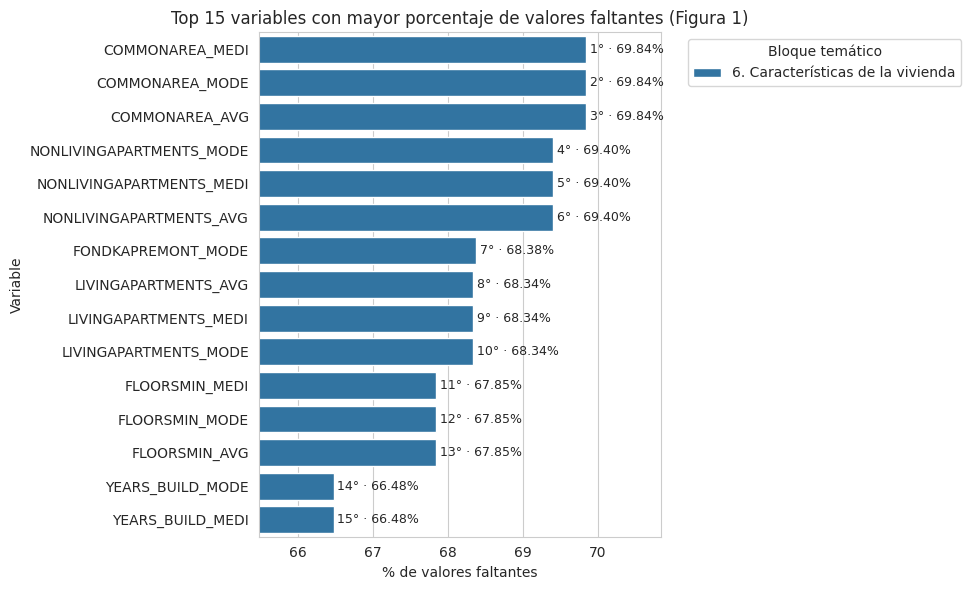

In [78]:
# Gráfico de barras top 15 variables con mayor % de nulos (Figura 1)
# Ajuste tras la devolución de la Evidencia 1: las barras originales se veían
# casi idénticas porque el eje arrancaba en 0 y todos los valores están entre
# 66% y 70%. Acotamos el eje al rango real de los datos y agregamos el
# ranking + porcentaje exacto sobre cada barra para que la diferencia sea legible.

plt.figure(figsize=(10, 6))
top15_nulos = resumen_nulos.head(15)

ax = sns.barplot(x=top15_nulos['pct_nulos'], y=top15_nulos.index,
                  hue=top15_nulos['bloque'], dodge=False)

minimo = top15_nulos['pct_nulos'].min()
maximo = top15_nulos['pct_nulos'].max()
plt.xlim(minimo - 1, maximo + 1)

for i, (valor, ranking) in enumerate(zip(top15_nulos['pct_nulos'], top15_nulos['ranking'])):
    ax.text(valor + 0.05, i, f'{ranking}° · {valor:.2f}%', va='center', fontsize=9)

plt.xlabel('% de valores faltantes')
plt.ylabel('Variable')
plt.title('Top 15 variables con mayor porcentaje de valores faltantes (Figura 1)')
plt.legend(title='Bloque temático', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **2.6 Distribución de la Variable Objetivo (TARGET)**

Analizamos cómo se reparten los clientes entre las **dos clases de `TARGET`
(0 = cumple, 1 = default).**
>Este paso es central para el resto del proyecto:
el grado de desbalance entre clases condiciona qué métricas de evaluación van
a ser útiles y qué técnicas de modelado va a ser necesario aplicar más
adelante.



Conteo absoluto:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Porcentaje:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


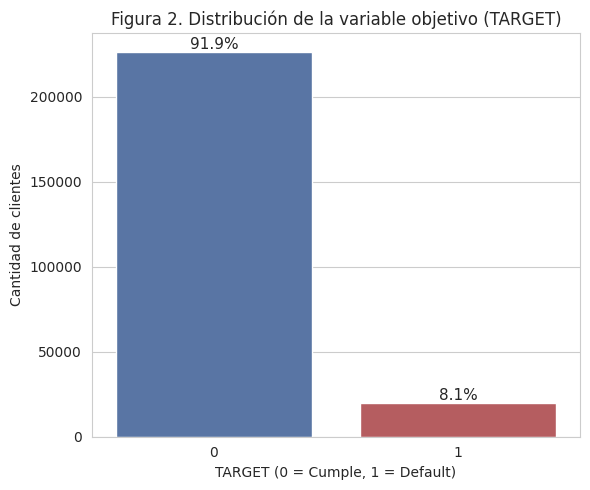

In [79]:
# TARGET solo tiene dos valores posibles (0 y 1), el resultado del conteo son dos números o tiene TARGET=0 o TARGET=1.
#conteo absoluto
conteo_target = train_df['TARGET'].value_counts()
#porcentual
pct_target = train_df['TARGET'].value_counts(normalize=True) * 100

print("Conteo absoluto:")
print(conteo_target)
print()
print("Porcentaje:")
print(pct_target.round(2))

plt.figure(figsize=(6, 5)) #tamaño grafico
#utilizamos sns.countplot / Seaborn que cuenta cuantas filas hay de cada valor en la columna que le indiques (x='TARGET') y devuelve el grafico
ax = sns.countplot(x='TARGET', data=train_df, hue='TARGET', palette=['#4C72B0', '#C44E52'], legend=False)
plt.xlabel('TARGET (0 = Cumple, 1 = Default)')
plt.ylabel('Cantidad de clientes')
plt.title('Figura 2. Distribución de la variable objetivo (TARGET)')

#agregamos el % arriba de cada barra
total = len(train_df)
#ax.patches es la lista con los objetos graficos que dibujo Seaborn — en este caso c/u de las barras
for p in ax.patches:
    pct = 100 * p.get_height() / total    #altura de la barra:porcentaje que representa c/barra sobre el total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

La variable `TARGET` presenta un **fuerte desbalance de clases** sobre el
conjunto de entrenamiento (`train_df`, 246.008 clientes):

- **TARGET = 0** (cumple correctamente sus pagos): 226.148 clientes → **91.93%**
- **TARGET = 1** (incumplimiento / default): 19.860 clientes → **8.07%**

**Lectura de negocio:** se puede interpretar que el 92% de los clientes históricos haya cumplido
con sus pagos es coherente con el criterio que ya aplica la entidad al
otorgar créditos. El foco del proyecto está en ese 8% minoritario: comprender
qué características comparten los clientes que terminan en default es lo
que le daría valor al modelo.

**Hipótesis a explorar en el resto del EDA:** dado este desbalance podemos creer que existen variables que muestren una distribución claramente distinta entre clientes cumplidores y no cumplidores. Por ejemplo:
- ¿Los clientes en default tienden a ser más jóvenes o con menor antigüedad laboral?
- ¿El nivel de ingresos o el monto del crédito solicitado se relaciona
  con el incumplimiento?
- ¿Los scores externos (`EXT_SOURCE_1/2/3`) que ya vimos vienen con
  muchos valores nulos, muestran valores más bajos en el grupo de default?

Estas hipótesis se retoman y responden en la Sección 3 (EDA), **donde se analiza cada variable en relación a `TARGET`.** Cabe aclarar que, para poder responderlas correctamente, antes va a ser necesario resolver algunos problemas de calidad de dato detectados en variables clave (por ejemplo, un
valor placeholder en `DAYS_EMPLOYED` que distorsiona la antigüedad laboral) que se documenta en el punto 3.5.

## **3. Análisis Exploratorio de Datos (EDA)**

En esta sección exploramos el conjunto de entrenamiento **`train_df` que tiene 246.008 clientes** para responder las dos preguntas que planteamos en la sección 1:

>Qué variables se comportan distinto entre los clientes que cumplen y los que
caen en default, y qué problemas de los datos habría que resolver antes de
entrenar un modelo.

El orden que seguimos es:

1. Primero preparamos algunas variables para poder
leerlas (3.0)
2. Después describimos los datos por bloques (3.1)
3. Miramos las distribuciones (3.2): comparamos cada variable contra TARGET (3.3), revisamos las correlaciones (3.4)

4. Finalmente juntamos todos los problemas de calidad
que fuimos encontrando (3.5).

**Todo el análisis se hace sobre `train_df`** (el test set queda sin tocar hasta la Evidencia 3).

### **3.0 Preparación de variables**

Tuvimos que resolver dos cosas que hacían difícil
leer los datos.

Dos variables en particular necesitaban ajuste antes de poder analizarlas: **`DAYS_BIRTH` y `DAYS_EMPLOYED`**, las que vamos a usar para explorar la primera hipótesis planteada en 2.6 (edad y antigüedad laboral).

> Ambas están expresadas en **días negativos** contados desde la fecha de la solicitud → por ejemplo, `DAYS_BIRTH = -15000` quiere decir que el cliente nació 15.000 días antes de
pedir el crédito. Para poder interpretarlas las pasamos a **años positivos.**

Además, al mirar `DAYS_EMPLOYED` nos encontramos con un valor centinela que se repetía muchísimo, y que si no lo separábamos rompía todos los estadísticos de esa variable.

Trabajamos sobre una copia (`eda_df`) para no modificar `train_df`.

In [80]:
# Copia de trabajo: no tocamos train_df
eda_df = train_df.copy()

# Buscamos el valor raro que nos llamó la atención en DAYS_EMPLOYED
CENTINELA = 365243   # son unos 1000 años de antigüedad laboral

mask_centinela = eda_df['DAYS_EMPLOYED'] == CENTINELA

print(f"Registros con DAYS_EMPLOYED = {CENTINELA}: {mask_centinela.sum():,} "
      f"({mask_centinela.mean()*100:.1f}% del train)")
print()
print("Qué tipo de cliente son:")
print(eda_df.loc[mask_centinela, 'NAME_INCOME_TYPE'].value_counts())
print()
print("Tasa de default de ese grupo vs. el resto:")
print(f"  Con el valor raro: {eda_df.loc[mask_centinela, 'TARGET'].mean()*100:.2f}%")
print(f"  Resto:             {eda_df.loc[~mask_centinela, 'TARGET'].mean()*100:.2f}%")

Registros con DAYS_EMPLOYED = 365243: 44,143 (17.9% del train)

Qué tipo de cliente son:
NAME_INCOME_TYPE
Pensioner     44126
Unemployed       17
Name: count, dtype: int64

Tasa de default de ese grupo vs. el resto:
  Con el valor raro: 5.37%
  Resto:             8.66%


In [81]:
# Pasamos las variables DAYS_* a años positivos
eda_df['YEARS_BIRTH']    = (-eda_df['DAYS_BIRTH'] / 365.25).round(1)
eda_df['YEARS_EMPLOYED'] = (-eda_df['DAYS_EMPLOYED'] / 365.25).round(1)

# Ponemos el valor raro como NaN, pero solo para explorar.
# No es un dato faltante de verdad: parece ser un código que usan
# para decir "este cliente no tiene empleo registrado".
eda_df.loc[mask_centinela, 'YEARS_EMPLOYED'] = np.nan

# Guardamos ese grupo en una columna aparte para poder mirarlo después
eda_df['SIN_EMPLEO_REGISTRADO'] = mask_centinela.astype(int)

# Comparamos cómo quedan los estadísticos con y sin el valor raro
comparacion = pd.DataFrame({
    'Con el valor raro': (-train_df['DAYS_EMPLOYED'] / 365.25).describe(),
    'Sin el valor raro': eda_df['YEARS_EMPLOYED'].describe()
})
print("Antigüedad laboral en años:")
print(comparacion.round(2))

Antigüedad laboral en años:
       Con el valor raro  Sin el valor raro
count          246008.00          201865.00
mean             -174.08               6.53
std               386.26               6.41
min              -999.98               0.00
25%                 0.80               2.10
50%                 3.33               4.50
75%                 7.56               8.70
max                49.04              49.00



El **valor 365243** aparece en el 18.0% de los registros, y todos corresponden a clientes con `NAME_INCOME_TYPE` igual a `'Pensioner'` o `'Unemployed'`. No parece un error aleatorio de carga sino **un código que usan para marcar que
el cliente no tiene empleo registrado.**

>Si no lo separamos, la antigüedad laboral promedio del dataset da 174.0 años aproximadamente, que obviamente no tiene sentido. Con el valor afuera queda en 6.5 años.

Nos llamó la atención que este grupo tiene una tasa de default más baja que el resto (5.4% vs. 8.7%). Tiene sentido si son en su mayoría jubilados, que tienen un ingreso fijo. *Esto es un cruce preliminar contra `TARGET` → el análisis completo de esta relación se retoma en 3.3 junto con el resto de las variables laborales,* pero ya nos hace pensar que la **condición de "no
tener empleo registrado" es información útil en sí misma,** así que en la Evidencia 2 conviene guardarla como variable en vez de simplemente rellenar la antigüedad con un promedio.

### **3.1 Descripción de los Datos por Bloques**

Usamos los bloques temáticos que armamos en 2.4 para no tener que ir columna por columna. Nos centramos en los cuatro bloques que más nos interesan para el problema: **demográficas, laborales, financieras y scores externos.**

En las tablas de demográficas y laborales incluimos tanto la variable original en días (`DAYS_BIRTH`, `DAYS_EMPLOYED`) como su versión convertida a años (`YEARS_BIRTH`, `YEARS_EMPLOYED`) que armamos en 3.0, a modo de comparación.

>Importante: `DAYS_EMPLOYED` todavía muestra el efecto del valor
centinela sin limpiar (su máximo va a aparecer disparado), mientras que `YEARS_EMPLOYED` ya tiene ese valor tratado como nulo.


In [82]:
def describir(cols, df=eda_df):
    """Estadísticos descriptivos + % de nulos de una lista de columnas numéricas."""
    cols = [c for c in cols if c in df.columns]
    num = df[cols].select_dtypes(include='number')
    tabla = num.describe().T
    tabla['nulos_%'] = (df[num.columns].isnull().mean() * 100).round(2)
    return tabla.round(2)


def describir_cat(cols, df=eda_df):
    """Para las categóricas: cuántas categorías tiene cada una y cuál domina."""
    cols = [c for c in cols if c in df.columns]
    cat = df[cols].select_dtypes(include='object')
    filas = []
    for c in cat.columns:
        vc = df[c].value_counts(normalize=True)
        filas.append({
            'variable': c,
            'categorías': df[c].nunique(),
            'más frecuente': vc.index[0],
            '% más frec.': round(vc.iloc[0] * 100, 1),
            'nulos_%': round(df[c].isnull().mean() * 100, 2)
        })
    return pd.DataFrame(filas)

In [83]:
print("Bloque 2 — Demográficas / personales")
display(describir(bloques_variables["2. Demográficas / personales"] + ['YEARS_BIRTH']))
display(describir_cat(bloques_variables["2. Demográficas / personales"]))

Bloque 2 — Demográficas / personales


,count,mean,std,min,25%,50%,75%,max,nulos_%
DAYS_BIRTH,246008.0,-16029.52,4362.87,-25229.0,-19673.0,-15744.0,-12401.0,-7489.0,0.0
CNT_CHILDREN,246008.0,0.42,0.72,0.0,0.0,0.0,1.0,19.0,0.0
CNT_FAM_MEMBERS,246006.0,2.15,0.91,1.0,2.0,2.0,3.0,20.0,0.0
YEARS_BIRTH,246008.0,43.89,11.94,20.5,34.0,43.1,53.9,69.1,0.0


,variable,categorías,más frecuente,% más frec.,nulos_%
0,CODE_GENDER,3,F,65.8,0.00
1,NAME_FAMILY_STATUS,6,Married,63.9,0.00
2,NAME_EDUCATION_TYPE,5,Secondary / secondary special,71.0,0.00
3,NAME_HOUSING_TYPE,6,House / apartment,88.8,0.00
4,NAME_TYPE_SUITE,7,Unaccompanied,81.2,0.42


In [84]:
print("Bloque 3 — Laborales")
display(describir(bloques_variables["3. Laborales"] + ['YEARS_EMPLOYED']))
display(describir_cat(bloques_variables["3. Laborales"]))

Bloque 3 — Laborales


,count,mean,std,min,25%,50%,75%,max,nulos_%
DAYS_EMPLOYED,246008.0,63581.16,141081.70,-17912.0,-2762.0,-1215.0,-291.0,365243.0,0.00
YEARS_EMPLOYED,201865.0,6.53,6.41,0.0,2.1,4.5,8.7,49.0,17.94


,variable,categorías,más frecuente,% más frec.,nulos_%
0,NAME_INCOME_TYPE,8,Working,51.6,0.00
1,OCCUPATION_TYPE,18,Laborers,26.2,31.28
2,ORGANIZATION_TYPE,58,Business Entity Type 3,22.1,0.00


In [85]:
print("Bloque 4 — Financieras del crédito")
display(describir(bloques_variables["4. Financieras del crédito"]))
display(describir_cat(bloques_variables["4. Financieras del crédito"]))

Bloque 4 — Financieras del crédito


,count,mean,std,min,25%,50%,75%,max,nulos_%
AMT_INCOME_TOTAL,246008.0,168853.18,258960.63,25650.0,112500.0,147600.0,202500.0,117000000.0,0.00
AMT_CREDIT,246008.0,599338.25,402725.77,45000.0,270000.0,514777.5,808650.0,4050000.0,0.00
AMT_ANNUITY,245998.0,27108.09,14520.90,1615.5,16510.5,24903.0,34596.0,258025.5,0.00
AMT_GOODS_PRICE,245787.0,538652.98,369595.05,40500.0,238500.0,450000.0,679500.0,4050000.0,0.09
OWN_CAR_AGE,83590.0,12.06,11.91,0.0,5.0,9.0,15.0,91.0,66.02


,variable,categorías,más frecuente,% más frec.,nulos_%
0,NAME_CONTRACT_TYPE,2,Cash loans,90.5,0.0
1,FLAG_OWN_CAR,2,N,66.0,0.0
2,FLAG_OWN_REALTY,2,Y,69.4,0.0


In [86]:
print("Bloque 5 — Scores externos")
display(describir(bloques_variables["5. Scores externos"]))

Bloque 5 — Scores externos


,count,mean,std,min,25%,50%,75%,max,nulos_%
EXT_SOURCE_1,107413.0,0.50,0.21,0.01,0.33,0.51,0.67,0.95,56.34
EXT_SOURCE_2,245477.0,0.51,0.19,0.00,0.39,0.57,0.66,0.85,0.22
EXT_SOURCE_3,197203.0,0.51,0.19,0.00,0.37,0.54,0.67,0.90,19.84


Lo que vimos en estas tablas:

En las **demográficas**, la edad va de 21 a 69 años con una media de 43.9, así que no hay valores imposibles. `CNT_CHILDREN` llega hasta 19 hijos, que es raro pero no imposible; lo revisamos en 3.5. `CNT_FAM_MEMBERS` tiene 2
nulos, que es nada sobre 246.000 filas.

En las **laborales**, una vez sacado el valor raro la antigüedad (`YEARS_EMPLOYED`) queda en 6.5 años de media el cual es muy distinto del máximo distorsionado que todavía muestra `DAYS_EMPLOYED` en días, tal como se explicó al principio de
esta sección. `OCCUPATION_TYPE` tiene 31.0% de nulos, bastante alto.

En las **financieras** apareció el problema más llamativo. `AMT_INCOME_TOTAL` tiene una media de 168.853 pero un máximo de 117.000.000. Además la mediana (147.600) está bastante por debajo de la media, que es la señal típica de que la distribución está estirada hacia la derecha por unos pocos valores muy grandes. `AMT_CREDIT`, `AMT_ANNUITY` y `AMT_GOODS_PRICE` tienen el mismo problema aunque más suave. Estos tres casos de asimetría extrema los retomamos en 3.5 junto con `CNT_CHILDREN`.

En cuanto a **nulos**, `AMT_INCOME_TOTAL` y `AMT_CREDIT` están completas, y `AMT_ANNUITY` casi (10 nulos sobre 246.008, un porcentaje tan bajo que redondea a 0.00%) y `AMT_GOODS_PRICE` también (0.09%). La excepción es `OWN_CAR_AGE`, con 66.02% de nulos — un porcentaje que coincide casi exactamente con el 66.0% de clientes que no tienen auto (`FLAG_OWN_CAR = 'N'`,
visible en la tabla categórica de este bloque). Es el mismo patrón de faltante estructural que ya habíamos visto en 2.5 con el bloque de vivienda: la variable no aplica, no es que el dato se haya perdido.

En los **scores externos**, los tres van de 0 a 1, así que ya vienen procesados por quien los calculó, y sus medias y medianas son similares entre sí (alrededor de 0.50-0.51), sin la asimetría marcada que vimos en el bloque financiero. Donde sí difieren es en la cantidad de datos disponibles:
`EXT_SOURCE_1` tiene 56.34% de nulos y `EXT_SOURCE_3` 19.84%, mientras que `EXT_SOURCE_2` está prácticamente completa (0.22% de nulos). Esta variable es la más completa de las tres, lo cual la vuelve la candidata más confiable
para explorar en 3.3.

### **3.2 Distribuciones de las Variables**

Graficamos las variables que nos parecieron más importantes, porque hay cosas (como la asimetría o los valores extremos) que en una tabla de estadísticos no se ven tan claras.

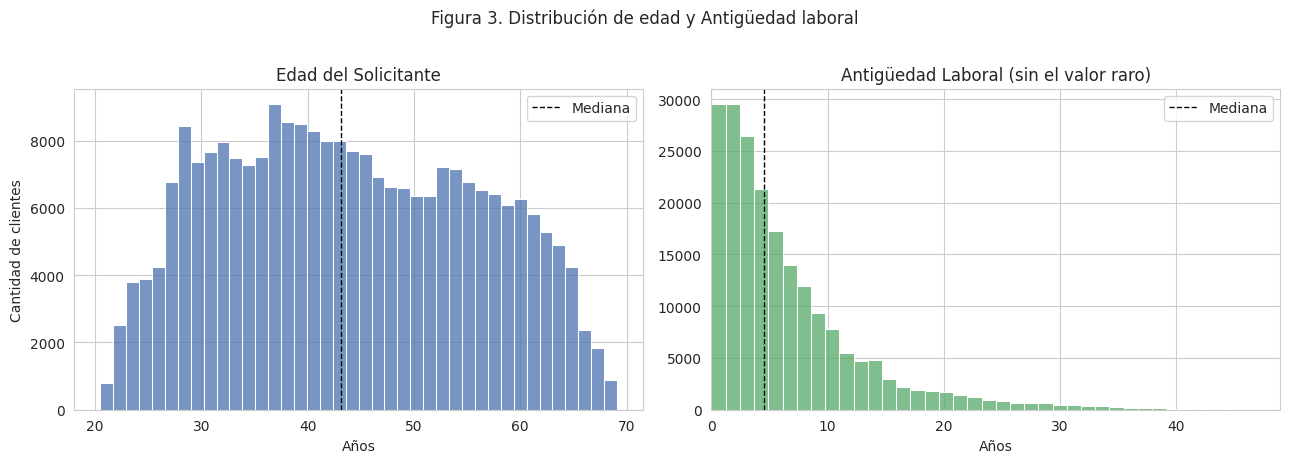

In [87]:
#Distribución de edad y Antigüedad laboral'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(eda_df['YEARS_BIRTH'], bins=40, color='#4C72B0', ax=axes[0])
axes[0].axvline(eda_df['YEARS_BIRTH'].median(), color='black', linestyle='--', linewidth=1, label='Mediana')
axes[0].set_title('Edad del Solicitante')
axes[0].set_xlabel('Años')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].legend()

sns.histplot(eda_df['YEARS_EMPLOYED'].dropna(), bins=40, color='#55A868', ax=axes[1])
axes[1].axvline(eda_df['YEARS_EMPLOYED'].median(), color='black', linestyle='--', linewidth=1, label='Mediana')
axes[1].set_title('Antigüedad Laboral (sin el valor raro)')
axes[1].set_xlabel('Años')
axes[1].set_ylabel('')
axes[1].set_xlim(0, eda_df['YEARS_EMPLOYED'].max())
axes[1].legend()

fig.suptitle('Figura 3. Distribución de edad y Antigüedad laboral', y=1.02)
plt.tight_layout()
plt.show()

Interpretación de los gráficos:
- **La edad del Solicitante** muestra una distribución razonablemente uniforme, con un leve pico entre los 35 y 40 años y sin valores que llamen la atención, consistente con los estadísticos de 3.1 (rango 21-69, media
y mediana cercanas entre sí).

- **La antigüedad Laboral**, en cambio muestra una asimetría marcada hacia la derecha: la mediana está en 4.4 años (línea punteada en el gráfico), muy cerca del pico de la distribución, y a partir de ahí la cantidad de casos cae rápido a medida que aumenta la antigüedad. A diferencia de la asimetría
que vimos en `AMT_INCOME_TOTAL` (3.1), acá no se trata de un problema de calidad de dato ni de outliers puntuales → **es la forma esperable de una variable de "tiempo en el empleo"**: lógicamente hay más gente recién ingresada que gente con muchos años en el mismo trabajo.

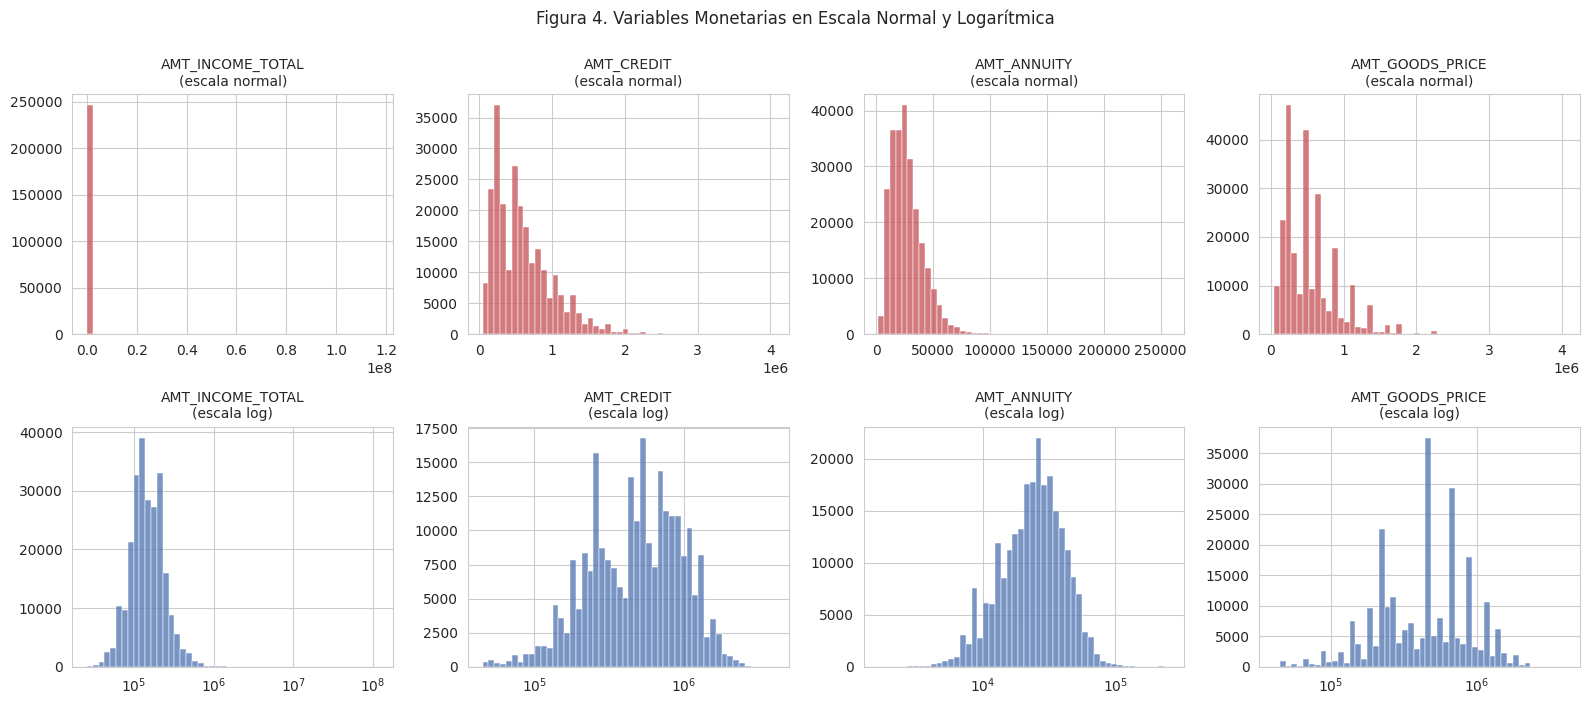

Asimetría (skewness):
AMT_INCOME_TOTAL    375.13
AMT_CREDIT            1.23
AMT_ANNUITY           1.60
AMT_GOODS_PRICE       1.35
dtype: float64


In [88]:
# Variables Monetarias en Escala Normal y Logarítmica

monetarias = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Arriba: escala normal
for i, col in enumerate(monetarias):
    sns.histplot(eda_df[col].dropna(), bins=50, ax=axes[0, i], color='#C44E52')
    axes[0, i].set_title(f'{col}\n(escala normal)', fontsize=10)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('')

# Abajo: escala logarítmica
for i, col in enumerate(monetarias):
    sns.histplot(eda_df[col].dropna(), bins=50, ax=axes[1, i],
                 color='#4C72B0', log_scale=True)
    axes[1, i].set_title(f'{col}\n(escala log)', fontsize=10)
    axes[1, i].set_xlabel('')
    axes[1, i].set_ylabel('')

fig.suptitle('Figura 4. Variables Monetarias en Escala Normal y Logarítmica', y=1.00)
plt.tight_layout()
plt.show()

print("Asimetría (skewness):")
print(eda_df[monetarias].skew().round(2))


**Variables involucradas**
- **`AMT_INCOME_TOTAL`**: ingreso total declarado por el cliente.
- **`AMT_CREDIT`**: monto del crédito efectivamente otorgado al cliente.
- **`AMT_ANNUITY`**: importe de la cuota periódica mediante la cual el
  cliente devuelve el crédito.
- **`AMT_GOODS_PRICE`**: precio del bien adquirido con el crédito

En conjunto, estas cuatro variables permiten caracterizar la capacidad
económica del solicitante (`AMT_INCOME_TOTAL`) y las condiciones del
préstamo solicitado (`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`),
por lo que se espera que guarden relación directa con el riesgo de
incumplimiento.

Interpretación de los gráficos:

- La **escala normal** (fila superior) deja ver la magnitud real del problema: en `AMT_INCOME_TOTAL` toda la distribución queda comprimida en una sola barra pegada al cero, producto del outlier extremo de 117.000.000 ya identificado en 3.1. Las otras tres variables muestran el mismo patrón de
cola larga hacia la derecha, aunque de forma menos extrema.

- La **escala logarítmica** (fila inferior) confirma que, en las cuatro, la distribución subyacente es aproximadamente log-normal (acampanada una vez aplicada la transformación) → el problema no es que los datos sean "raros", sino que están en una escala donde los valores altos dominan visualmente sobre el resto.

- El **coeficiente de asimetría (skewness)** cuantifica esta diferencia: mientras `AMT_CREDIT` (1.23), `AMT_GOODS_PRICE` (1.35) y `AMT_ANNUITY` (1.60) muestran un sesgo moderado, típico de variables monetarias, `AMT_INCOME_TOTAL` tiene un skewness de 375.13 → un valor completamente fuera de escala respecto
a las otras tres, que confirma que no se trata de una asimetría "normal" sino del efecto de un número muy reducido de valores extremos.

**Aclaración**: dado que el modelo a
usar es una regresión logística, sensible tanto a la escala de las variables como a valores extremos, estas variables monetarias van anecesitar algún tipo de transformación (por ejemplo, logarítmica) antes de entrenar el modelo.

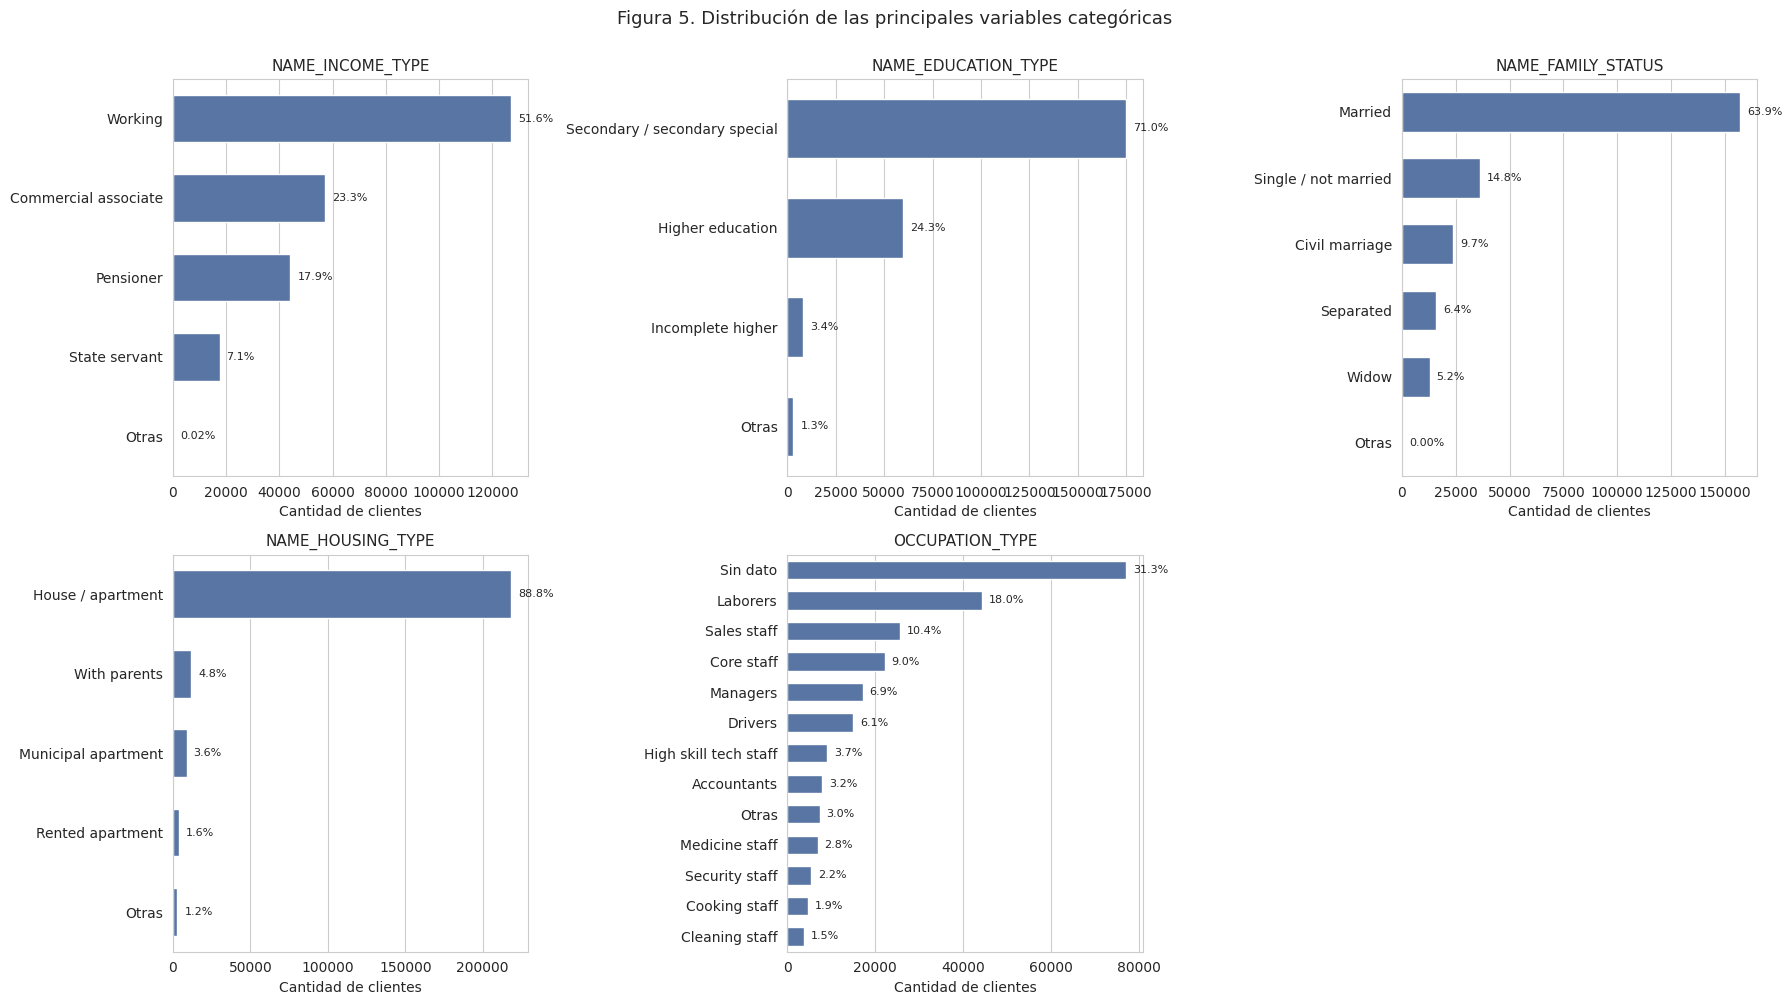

In [89]:
# Distribución de las Principales Variables Categóricas

categoricas = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
               'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

def agrupar_categorias(serie, umbral_pct=1.5, incluir_nulos=False):
    """Agrupa categorías con menos de umbral_pct% en 'Otras'.
    Si incluir_nulos=True, trata los NaN como una categoría 'Sin dato'
    en vez de descartarlos (relevante para OCCUPATION_TYPE)."""
    s = serie.fillna('Sin dato') if incluir_nulos else serie.dropna()
    conteo = s.value_counts()
    total = conteo.sum()
    pct = (conteo / total * 100)
    principales = conteo[pct >= umbral_pct].copy()
    resto = conteo[pct < umbral_pct].sum()
    if resto > 0:
        principales['Otras'] = resto
    return principales.sort_values(ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

for i, col in enumerate(categoricas):
    incluir_nulos = (col == 'OCCUPATION_TYPE')
    datos = agrupar_categorias(eda_df[col], umbral_pct=1.5, incluir_nulos=incluir_nulos)
    total = datos.sum()

    ax = axes[i]
    sns.barplot(x=datos.values, y=datos.index, ax=ax, color='#4C72B0', width=0.6)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Cantidad de clientes')
    ax.set_ylabel('')

    for j, valor in enumerate(datos.values):
      pct = valor / total * 100
      etiqueta = f'{pct:.2f}%' if pct < 0.1 else f'{pct:.1f}%'
      ax.annotate(etiqueta, (valor, j), va='center', ha='left', fontsize=8, xytext=(5, 0),
                textcoords='offset points')

# Ocultamos el sexto panel vacío (5 variables en un grid de 6)
axes[5].set_visible(False)

fig.suptitle('Figura 5. Distribución de las principales variables categóricas', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

Interpretación de los gráficos:

El agrupamiento de categorías minoritarias confirma el patrón de dominancia que se veía en la versión anterior de esta figura, ahora cuantificado:
- **`Working`** concentra el 51.6% de los solicitantes en NAME_INCOME_TYPE
- **`Secondary / secondary special`** el 71.0% en NAME_EDUCATION_TYPE
- **`Married`** el 63.9% NAME_FAMILY_STATUS
- **`House / apartment`** el 88.8% en NAME_HOUSING_TYPE → este último es el caso más extremo de las cuatro.

El panel más relevante para el problema de negocio es OCCUPATION_TYPE:

- **Sin ocupación registrada:**
>Es el **31.3% de los solicitantes** (tratado acá como categoría "Sin dato" en vez de descartarse, a diferencia del resto de las variables), consistente con el hallazgo de nulos de 3.1.
- **Con ocupación registrada:**,
>  **`Laborers`** es la ocupación más frecuente (18.0%),
seguida de `Sales staff` → **10.4%** y **`Core staff`** → **9.0%**, con una cola larga de ocupaciones minoritarias agrupadas en **"Otras" (3.0%)**.

In [90]:
eda_df['NAME_EDUCATION_TYPE'].value_counts()

,count
NAME_EDUCATION_TYPE,
Secondary / secondary special,174768
Higher education,59802
Incomplete higher,8289
Lower secondary,3025
Academic degree,124



### **3.3 Relación de las Variables con TARGET**

En esta sección se analiza qué variables permiten distinguir a los
clientes que cumplieron con sus pagos de los que incurrieron en
incumplimiento. Para ello, se agrupan los clientes según el valor de
`TARGET`:

- **Grupo "Cumple" (`TARGET = 0`)**: clientes que pagaron su crédito
  correctamente.
- **Grupo "Default" (`TARGET = 1`)**: clientes que presentaron
  incumplimiento.

El análisis consiste en comparar, para cada variable, cómo se comporta
esa variable dentro de cada uno de estos dos grupos, con el objetivo de
identificar diferencias que puedan anticipar el riesgo de incumplimiento.

Es importante aclarar que, dado el desbalance de clases observado en la
Sección 2.6 (92% vs. 8%), **no resulta adecuado comparar la cantidad
absoluta de clientes en default por categoría**, ya que cualquier
categoría con muchos clientes tendrá naturalmente más casos de default
solo por su tamaño. Por este motivo, se utiliza la **tasa de default**
(el porcentaje de clientes en default *dentro de cada grupo*), comparada
contra la tasa general del 8.07%.



#### **3.3.1 Variables Numéricas**

Para cada variable numérica relevante, comparamos su **media, mediana y desvío estándar** entre los dos grupos de **`TARGET`**. Incluimos la mediana además de la media porque algunas de estas variables (como `AMT_INCOME_TOTAL`, con el skewness de 375.13 que vimos en 3.2) son muy sensibles a valores extremos y en esos casos, la mediana es la lectura más confiable.


**Las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3`**

Refieren a **puntajes normalizados provenientes de fuentes de información
externas** a la entidad financiera, según indica la documentación oficial
del dataset. No se detalla públicamente qué mide cada fuente en
particular, pero conceptualmente funcionan de forma similar a un
**"puntaje de crédito"**: valores entre 0 y 1, donde un puntaje más alto
indica, en principio, menor riesgo asociado al solicitante.

Se incluyen tres variables (`EXT_SOURCE_1`, `2` y `3`) porque provienen
de tres fuentes distintas, cada una con su propio criterio de cálculo

In [91]:
# Comparación de una variable entre los dos grupos de TARGET

def comparar_vs_target(col, df=eda_df):
    """Compara los estadísticos de una variable entre los dos grupos de TARGET."""
    tabla = df.groupby('TARGET')[col].agg(['count', 'mean', 'median', 'std']).round(3)
    tabla.index = ['TARGET=0 (cumple)', 'TARGET=1 (default)']
    return tabla

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
            'YEARS_BIRTH', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']:
    print(f"--- {col} ---")
    display(comparar_vs_target(col))

--- EXT_SOURCE_1 ---


,count,mean,median,std
TARGET=0 (cumple),99368,0.511,0.517,0.209
TARGET=1 (default),8045,0.386,0.361,0.205


--- EXT_SOURCE_2 ---


,count,mean,median,std
TARGET=0 (cumple),225658,0.523,0.574,0.186
TARGET=1 (default),19819,0.411,0.441,0.213


--- EXT_SOURCE_3 ---


...

,count,mean,median,std
TARGET=0 (cumple),184375,6.678,4.6,6.500
TARGET=1 (default),17490,4.966,3.4,5.053


--- AMT_INCOME_TOTAL ---


,count,mean,median,std
TARGET=0 (cumple),226148,169062.453,148500.0,109181.661
TARGET=1 (default),19860,166470.173,135000.0,833649.557


--- AMT_CREDIT ---


,count,mean,median,std
TARGET=0 (cumple),226148,603014.441,518562.0,407062.917
TARGET=1 (default),19860,557477.051,495216.0,346835.078


Los **scores externos** muestran la diferencia más marcada entre los dos grupos: en las tres variables, los clientes en default tienen una media entre 0.11 y 0.13 puntos más baja que los que cumplen (en una escala de 0 a 1), y la diferencia de medianas es todavía mayor (0.13 a 0.17 puntos), confirmando con claridad la hipótesis planteada en 2.6.

En `AMT_INCOME_TOTAL` y `AMT_CREDIT`, en cambio, la diferencia de medianas entre ambos grupos es chica (por ejemplo, 148.500 vs. 135.000 en ingresos): los montos por sí solos no parecen separar bien a los dos grupos (retomamos
esto más abajo, después de la Figura 8).

Sí notamos algo llamativo en`AMT_INCOME_TOTAL`: el desvío estándar del grupo en default (833.650) es
más de 7 veces el del grupo que cumple (109.182), a pesar de tener medias y medianas parecidas → **esto sugiere que el outlier extremo de ingresos que identificamos en 3.1 pertenece al grupo de clientes en default (`TARGET=1`), y por sí solo infla la dispersión de ese subgrupo.** Lo agregamos como punto de
atención para 3.5.


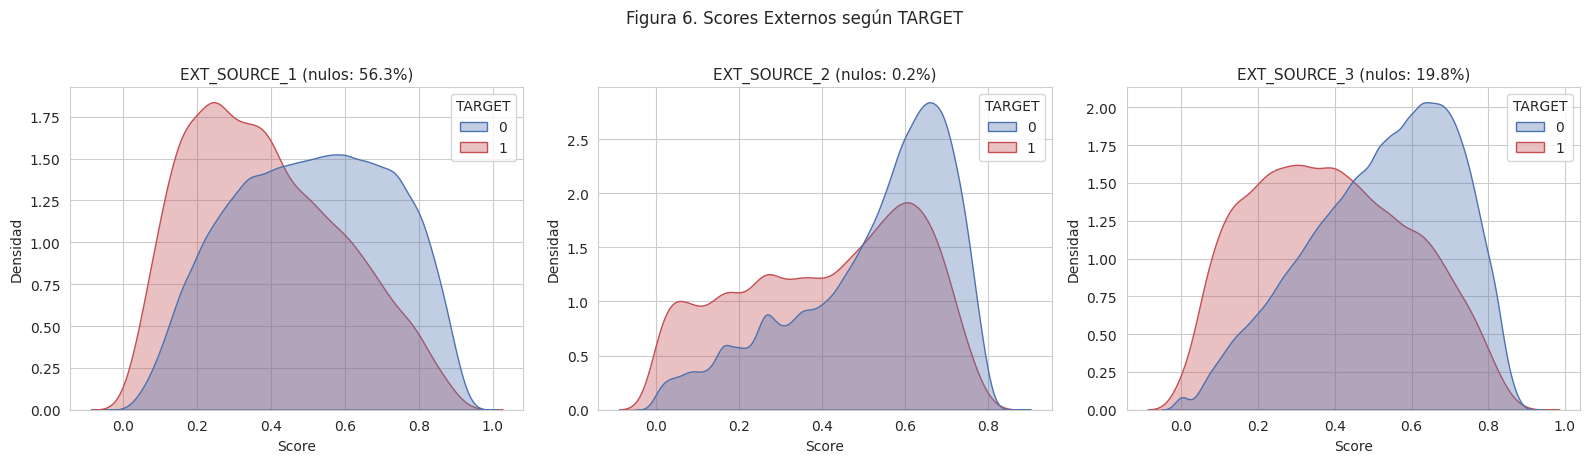

In [92]:
# Scores externos según TARGET'

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=eda_df, x=col, hue='TARGET', common_norm=False,
                fill=True, alpha=0.35, palette=['#4C72B0', '#C44E52'], ax=ax)
    ax.set_title(f'{col} (nulos: {eda_df[col].isnull().mean()*100:.1f}%)', fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Densidad')

fig.suptitle('Figura 6. Scores Externos según TARGET', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

>Los **scores externos** son las variables que mejor separan los dos grupos.

Se ve claramente que los clientes en default se concentran en los valores bajos de cada score, y los que cumplen en los valores altos → la diferencia de medias en `EXT_SOURCE_3` es de aproximadamente 0.10 puntos.

El problema es que justo son las variables con más nulos (56.3% en `EXT_SOURCE_1`, ver 3.1), así que en la Evidencia 2 vamos a tener que pensar bien cómo tratarlos: si las descartamos por los faltantes, perdemos lo que más parece servir para predecir.

Además de comparar los valores del score entre grupos, vale la pena chequear si el propio hecho de tener el dato disponible varía según TARGET →  **si a los clientes en default les falta el score con más frecuencia que a los que cumplen.**

In [93]:
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    pct_nulos_target = (eda_df.groupby('TARGET')[col]
                              .apply(lambda x: x.isnull().mean() * 100)
                              .round(2))
    pct_nulos_target.index = ['TARGET=0 (cumple)', 'TARGET=1 (default)']
    print(f"--- % de nulos en {col}, por grupo ---")
    print(pct_nulos_target)
    print()

--- % de nulos en EXT_SOURCE_1, por grupo ---
TARGET=0 (cumple)     56.06
TARGET=1 (default)    59.49
Name: EXT_SOURCE_1, dtype: float64

--- % de nulos en EXT_SOURCE_2, por grupo ---
TARGET=0 (cumple)     0.22
TARGET=1 (default)    0.21
Name: EXT_SOURCE_2, dtype: float64

--- % de nulos en EXT_SOURCE_3, por grupo ---
TARGET=0 (cumple)     19.58
TARGET=1 (default)    22.80
Name: EXT_SOURCE_3, dtype: float64



El patrón es consistente en dos de las tres variables:

- En `EXT_SOURCE_1`, los clientes en default tienen nulos en el 59.49% de los casos, contra 56.06% en los que cumplen (+3.43 puntos)
- En `EXT_SOURCE_3`, 22.80% contra 19.58% (+3.22 puntos)
- En `EXT_SOURCE_2` la diferencia es prácticamente nula
(0.21% vs. 0.22%), esperable dado que esta variable ya está casi completa en general.

Esto sugiere que **la ausencia del score no es completamente aleatoria** → los clientes en default tienden a no tener estos scores calculados con algo más de frecuencia que los que cumplen.

No es una diferencia enorme, pero sí consistente en dirección en ambas variables con nulos relevantes.

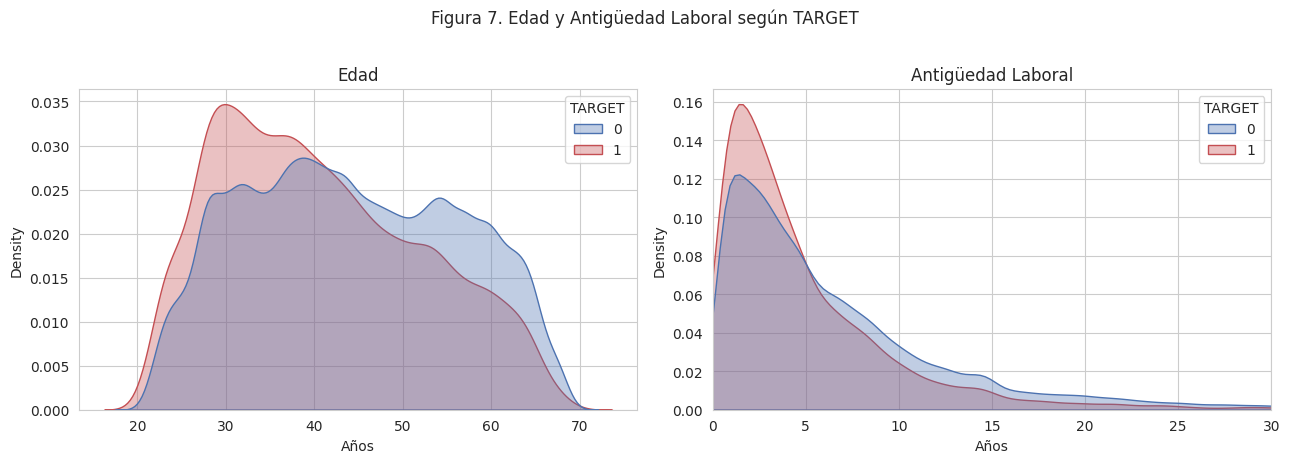

In [94]:
# Edad y Antigüedad Laboral según TARGET

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(data=eda_df, x='YEARS_BIRTH', hue='TARGET', common_norm=False,
            fill=True, alpha=0.35, palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Edad')
axes[0].set_xlabel('Años')

sns.kdeplot(data=eda_df.dropna(subset=['YEARS_EMPLOYED']), x='YEARS_EMPLOYED',
            hue='TARGET', common_norm=False, fill=True, alpha=0.35,
            palette=['#4C72B0', '#C44E52'], ax=axes[1])
axes[1].set_title('Antigüedad Laboral')
axes[1].set_xlabel('Años')
axes[1].set_xlim(0, 30)

fig.suptitle('Figura 7. Edad y Antigüedad Laboral según TARGET', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

**La antigüedad laboral va en el mismo sentido que la edad:** los clientes en default tienen, en promedio, 4.97 años de antigüedad laboral contra 6.68 años de los que cumplen (mediana: 3.4 vs. 4.6 años).
>Tiene sentido si pensamos que la estabilidad laboral es una forma indirecta de medir la estabilidad del ingreso → alguien con más años en el mismo puesto
probablemente tenga un flujo de ingresos más predecible.



In [95]:
# Armamos tramos de edad para ver la tasa de default de forma más concreta
eda_df['TRAMO_EDAD'] = pd.cut(eda_df['YEARS_BIRTH'],
                              bins=[20, 25, 30, 35, 40, 50, 60, 70],
                              labels=['20-25', '25-30', '30-35', '35-40',
                                      '40-50', '50-60', '60-70'])

tasa_edad = (eda_df.groupby('TRAMO_EDAD', observed=True)['TARGET']
                   .agg(clientes='size', tasa_default='mean'))
tasa_edad['tasa_default'] = (tasa_edad['tasa_default'] * 100).round(2)
print(tasa_edad)

            clientes  tasa_default
TRAMO_EDAD                        
20-25           9991         12.42
25-30          26572         11.12
30-35          31618         10.33
35-40          34293          8.90
40-50          61186          7.64
50-60          54474          6.05
60-70          27874          4.93


Los tramos de edad muestran algo más contundente que la simple comparación de medias: la tasa de default **baja de forma monótona** en cada tramo, sin ninguna excepción → de 12.42% en el tramo más joven (20-25 años) a 4.93% en el más viejo (60-70 años), una diferencia de 2.5 veces entre extremos. Que
la **caída sea gradual y consistente en los siete tramos,** y no un salto puntual en algún punto, refuerza que la **edad tiene una relación real y estable con el riesgo**, no un efecto producido por un grupo chico o atípico.
>Esto responde afirmativamente a la primera pregunta que
habíamos dejado abierta en 2.6: **los clientes más jóvenes efectivamente muestran mayor riesgo de incumplimiento.**

#### **3.3.2 Variables Categóricas**

Como ya explicamos en la introducción de esta sección, **comparamos la tasa de default de cada categoría (no la cantidad absoluta de defaults) contra la tasa general del 8.07%**, para no confundir "categoría grande" con "categoría riesgosa".

In [96]:
# Tasa de Default por Categoría

def tasa_default(col, df=eda_df, min_clientes=100):
    """Tasa de default por categoría. Filtra las categorías con muy pocos casos."""
    tabla = (df.groupby(col, dropna=False)['TARGET']
               .agg(clientes='size', defaults='sum', tasa_default='mean'))
    tabla['tasa_default'] = (tabla['tasa_default'] * 100).round(2)
    tabla = tabla[tabla['clientes'] >= min_clientes]
    return tabla.sort_values('tasa_default', ascending=False)


TASA_GLOBAL = eda_df['TARGET'].mean() * 100
print(f"Tasa de default general: {TASA_GLOBAL:.2f}%\n")

for col in ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
            'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR']:
    print(f"--- {col} ---")
    display(tasa_default(col))

Tasa de default general: 8.07%

--- NAME_EDUCATION_TYPE ---


,clientes,defaults,tasa_default
NAME_EDUCATION_TYPE,,,
Lower secondary,3025,335,11.07
Secondary / secondary special,174768,15582,8.92
Incomplete higher,8289,715,8.63
Higher education,59802,3226,5.39
Academic degree,124,2,1.61


--- NAME_INCOME_TYPE ---


,clientes,defaults,tasa_default
NAME_INCOME_TYPE,,,
Working,127043,12118,9.54
Commercial associate,57273,4348,7.59
State servant,17518,1024,5.85
Pensioner,44134,2365,5.36


--- NAME_FAMILY_STATUS ---


...

,clientes,defaults,tasa_default
NAME_CONTRACT_TYPE,,,
Cash loans,222560,18572,8.34
Revolving loans,23448,1288,5.49


--- CODE_GENDER ---


,clientes,defaults,tasa_default
CODE_GENDER,,,
M,84119,8526,10.14
F,161887,11334,7.00


--- FLAG_OWN_CAR ---


,clientes,defaults,tasa_default
FLAG_OWN_CAR,,,
N,162413,13779,8.48
Y,83595,6081,7.27


**El nivel educativo separa bastante bien a los dos grupos.**
- `Lower secondary` muestra una tasa de default de 11.07%, mientras que `Academic degree` muestra 1.61% → casi 7 veces de diferencia entre los extremos.

Vale aclarar que `Academic degree` tiene solo 124 clientes en
`train_df` (335 defaults en Lower secondary contra apenas 2 en Academic degree), así que aunque supera el filtro de `min_clientes` de la función, es una base bastante más chica que el resto de las categorías → la comparación es válida, pero con menos respaldo estadístico que las demás.

**El tipo de ingreso muestra el mismo tipo de gradiente.**
- `Working` tiene la tasa más alta (9.54%) y `Pensioner` la más baja (5.36%), con `Commercial associate` y `State servant` en un punto intermedio.
- Las categorías `Unemployed`, `Student`, `Businessman` y `Maternity leave`, visibles en la Figura 5 pero con muy pocos casos → no aparecen en esta tabla porque no superan el umbral mínimo de 100 clientes que usa la función `tasa_default()`.

De las otras cuatro variables categóricas analizadas, tres muestran diferencias que vale la pena registrar y una se mantiene cerca de la tasa general:

- `CODE_GENDER`: los hombres muestran una tasa de default más alta
  (10.14%) que las mujeres (7.00%).
- `NAME_CONTRACT_TYPE`: los créditos de tipo `Cash loans` tienen una tasa
  de default de 8.34%, más del doble que los `Revolving loans` (5.49%).
- `NAME_FAMILY_STATUS`: va de 5.87% (`Widow`) a 10.02% (`Civil marriage`), una diferencia mayor a la esperada dado que en 3.2 esta variable aparecía como la más balanceada del bloque en términos de cantidad de clientes por categoría → acá se ve que balance en composición no implica balance en riesgo.
- `FLAG_OWN_CAR` es la que menos separa: 8.48% (no tiene auto) contra
  7.27% (tiene auto), ambas tasas cercanas a la tasa general del 8.07%.

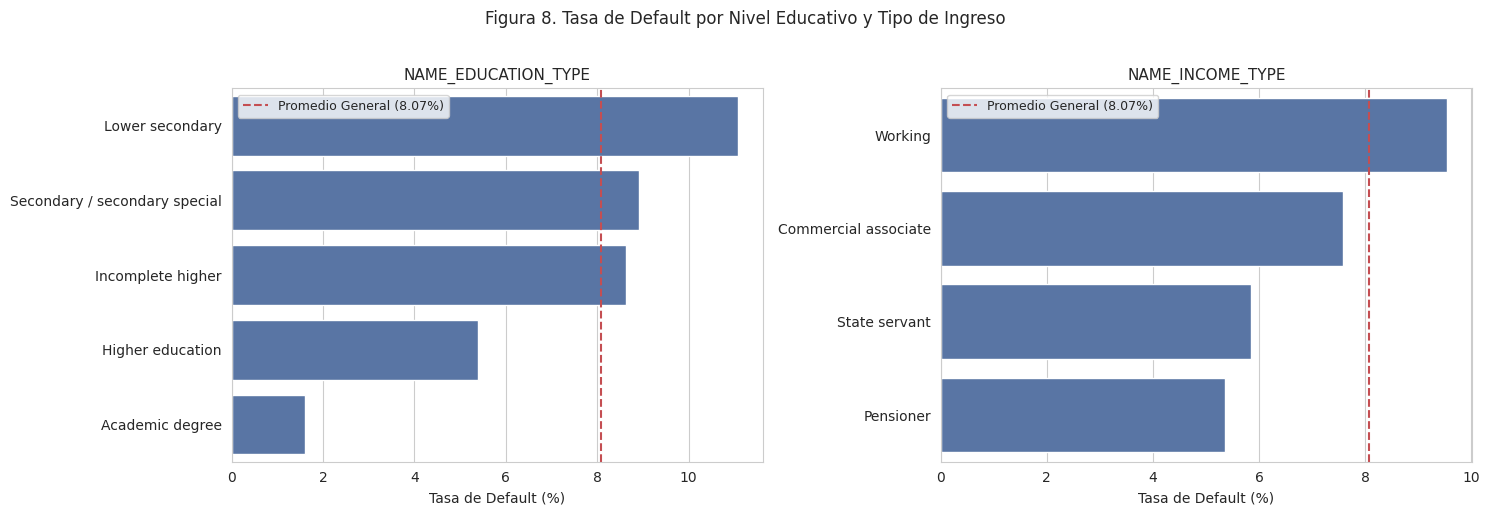

In [97]:
# Tasa de Default por Nivel Educativo y Tipo de Ingreso

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in zip(axes, ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']):
    t = tasa_default(col).reset_index()
    sns.barplot(data=t, y=col, x='tasa_default', ax=ax, color='#4C72B0')
    ax.axvline(TASA_GLOBAL, color='#C44E52', linestyle='--', linewidth=1.5,
               label=f'Promedio General ({TASA_GLOBAL:.2f}%)')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Tasa de Default (%)')
    ax.set_ylabel('')
    ax.legend(fontsize=9)

fig.suptitle('Figura 8. Tasa de Default por Nivel Educativo y Tipo de Ingreso', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

- En **educación**, la tasa de default baja de forma escalonada a medida que aumenta el nivel educativo, con `Lower secondary` (11.07%) muy por encima del promedio general (línea punteada, 8.07%) y `Academic degree` (1.61%) muy por debajo.
- En **tipo de ingreso**, `Working` es la única categoría por encima del promedio (9.54%); las otras tres: `Commercial associate`, `State servant` y `Pensioner` → quedan por debajo, con `Pensioner` como la de menor riesgo (5.36%).

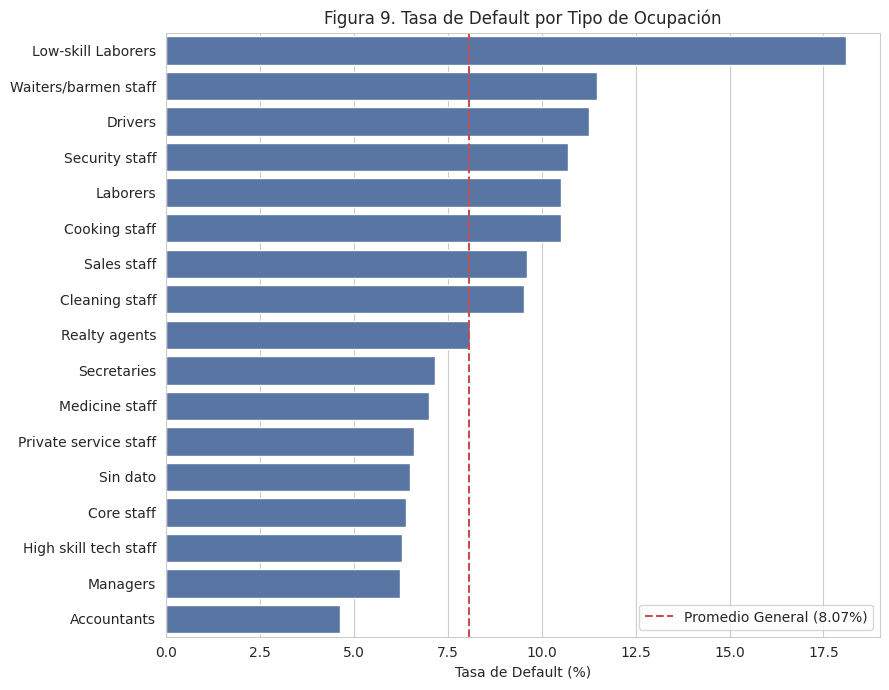

In [98]:
# Tasa de Default por Tipo de Ocupación

# Reemplazar los nulos por un string legible antes de calcular la tasa
eda_df['OCCUPATION_TYPE_FILLED'] = eda_df['OCCUPATION_TYPE'].fillna('Sin dato')
t_ocup = tasa_default('OCCUPATION_TYPE_FILLED', min_clientes=500).reset_index()

plt.figure(figsize=(9, 7))
sns.barplot(data=t_ocup, y='OCCUPATION_TYPE_FILLED', x='tasa_default', color='#4C72B0')
plt.axvline(TASA_GLOBAL, color='#C44E52', linestyle='--', linewidth=1.5,
            label=f'Promedio General ({TASA_GLOBAL:.2f}%)')
plt.title('Figura 9. Tasa de Default por Tipo de Ocupación')
plt.xlabel('Tasa de Default (%)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

In [99]:
display(t_ocup)

,OCCUPATION_TYPE_FILLED,clientes,defaults,tasa_default
0,Low-skill Laborers,1696,307,18.10
1,Waiters/barmen staff,1046,120,11.47
2,Drivers,14944,1683,11.26
3,Security staff,5372,574,10.69
4,Laborers,44259,4657,10.52
5,Cooking staff,4767,501,10.51
6,Sales staff,25606,2458,9.60
7,Cleaning staff,3741,357,9.54
8,Realty agents,594,48,8.08
9,Secretaries,1047,75,7.16


La **ocupación** muestra el rango más amplio de tasas de default de todas las categóricas analizadas: desde 18.10% en `Low-skill Laborers` hasta 4.63% en`Accountants` → una diferencia de casi 4 veces.

El **patrón es consistente** con lo que ya vimos en educación:
- Ocupaciones de **menor calificación y menor estabilidad** (`Low-skill Laborers`, `Waiters/barmen staff`, `Drivers`,
`Security staff`) → muestran las **tasas más altas**
- Ocupaciones **profesionales o gerenciales** (`Accountants`, `Managers`, `High skill tech staff`) → muestran las **más bajas**, todas por debajo del promedio general.

La categoría **"Sin dato"** (clientes sin ocupación registrada, el 31.3% del dataset identificado en 3.1) → muestra una tasa de default de 6.49% ,por debajo del promedio general (8.07%), **es decir, menor riesgo, no mayor.**

>Esto va en la dirección contraria a lo que vimos con la ausencia de los `EXT_SOURCE_*` (donde faltar el dato se asociaba a más riesgo), pero es consistente con otro hallazgo de la sección: en 3.0 ya habíamos visto que
el grupo sin empleo registrado en `DAYS_EMPLOYED` (compuesto en su mayoría por jubilados) también mostraba menor tasa de default que el resto.

*Es razonable pensar que ambos grupos se superponen en buena medida, un jubilado no tiene ocupación activa que declarar.*

### **3.4 Correlaciones**

Miramos las correlaciones por dos motivos:
- Ver qué variables se relacionan más con TARGET
- Detectar variables que estén repitiendo la misma información.

Lo segundo importa porque → en regresión logística, **si dos variables dicen prácticamente lo mismo, los coeficientes se vuelven inestables y difíciles de interpretar.**


In [100]:
# Correlación de cada variable numérica con TARGET
num_cols = eda_df.select_dtypes(include='number').columns.drop(
    ['TARGET', 'SK_ID_CURR', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
)
corr_target = eda_df[num_cols].corrwith(eda_df['TARGET']).sort_values()

print("Las 10 correlaciones más negativas (a mayor valor, menos default):")
display(corr_target.head(10).round(4).to_frame('correlación'))

print("Las 10 más positivas (a mayor valor, más default):")
display(corr_target.tail(10).sort_values(ascending=False).round(4).to_frame('correlación'))


Las 10 correlaciones más negativas (a mayor valor, menos default):


,correlación
EXT_SOURCE_3,-0.1788
EXT_SOURCE_2,-0.1596
EXT_SOURCE_1,-0.1554
YEARS_BIRTH,-0.0795
YEARS_EMPLOYED,-0.0752
SIN_EMPLEO_REGISTRADO,-0.0464
FLOORSMAX_AVG,-0.0437
FLOORSMAX_MEDI,-0.0435
FLOORSMAX_MODE,-0.0427
AMT_GOODS_PRICE,-0.0399


Las 10 más positivas (a mayor valor, más default):


,correlación
REGION_RATING_CLIENT_W_CITY,0.0613
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0538
REG_CITY_NOT_WORK_CITY,0.0517
DAYS_ID_PUBLISH,0.0496
FLAG_EMP_PHONE,0.0464
REG_CITY_NOT_LIVE_CITY,0.0457
FLAG_DOCUMENT_3,0.0443
DAYS_REGISTRATION,0.0421
OWN_CAR_AGE,0.0383


**Ninguna variable numérica individual tiene una correlación fuerte con TARGET:** incluso la más alta (`EXT_SOURCE_3`, -0.1788) se considera una correlación débil en términos estadísticos.

>Esto es consistente con la naturaleza del problema: **el riesgo de incumplimiento depende de una combinación de muchos factores, no de un único predictor dominante** → lo cual refuerza por qué hace falta un modelo que combine variables, y no alcanza con mirar una sola.

- Del lado de las **correlaciones negativas** (mayor valor → menos riesgo), el ranking confirma lo que ya habíamos visto en 3.3: **lideran los tres `EXT_SOURCE_`, seguidos de `YEARS_BIRTH` y `YEARS_EMPLOYED`**, y aparece `SIN_EMPLEO_REGISTRADO` (creada en 3.0) confirmando con un número el hallazgo descriptivo de esa sección.

  Las tres variantes de `FLOORSMAX` (`_AVG`, `_MEDI`, `_MODE`) aparecen con valores casi idénticos entre sí → es un indicio de que están altamente correlacionadas entre ellas, algo que confirmamos o descartamos en la matriz de correlación completa más abajo.

- Del lado de las **correlaciones positivas** (mayor valor → más riesgo), aparecen variables que no habíamos explorado en 3.3: `REGION_RATING_CLIENT` y su variante `_W_CITY`
tienen una lectura de negocio razonable → **peor calificación de la región de residencia se asocia a más riesgo**.

  El resto: variables de trámite y documentación como `DAYS_LAST_PHONE_CHANGE` o `FLAG_DOCUMENT_3` → muestran
  correlaciones más débiles (0.04-0.05) y sin una explicación de negocio tan directa; las dejamos anotadas pero preferimos no forzar una interpretación causal sin un análisis más profundo.

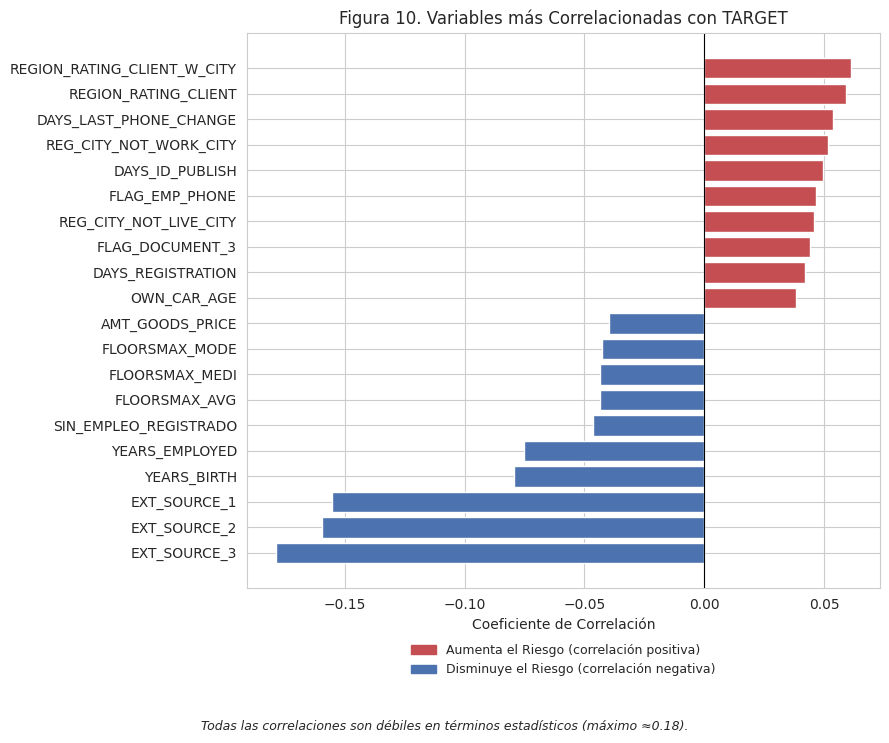

In [101]:
# Variables más Correlacionadas con TARGET

import matplotlib.patches as mpatches

top_corr = pd.concat([corr_target.head(10), corr_target.tail(10)]).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colores = ['#4C72B0' if v < 0 else '#C44E52' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colores)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_title('Figura 10. Variables más Correlacionadas con TARGET')
ax.set_xlabel('Coeficiente de Correlación')

# Leyenda de color, ubicada debajo del xlabel (fuera del área del gráfico)
rojo_patch = mpatches.Patch(color='#C44E52', label='Aumenta el Riesgo (correlación positiva)')
azul_patch = mpatches.Patch(color='#4C72B0', label='Disminuye el Riesgo (correlación negativa)')
ax.legend(handles=[rojo_patch, azul_patch], loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=9, frameon=False)

# Nota de escala
fig.text(0.5, -0.05,
         'Todas las correlaciones son débiles en términos estadísticos (máximo ≈0.18).',
         ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

Interpretación del gráfico:

Resume el ranking completo:
- En rojo las variables que aumentan
el riesgo de default a medida que crecen.
- En azul las que lo disminuyen.

Los `EXT_SOURCE_*` y la edad/antigüedad laboral encabezan el **lado que reduce el riesgo**, mientras que la calificación de la región (`REGION_RATING_CLIENT`) encabeza el **lado que lo aumenta.**
> Aun así, ninguna correlación es fuerte en términos estadísticos (máximo ≈0.18), **lo que confirma que el riesgo depende de una combinación de variables, no de un único factor dominante.**

Además del gráfico, **buscamos de forma sistemática si hay pares de variables que estén midiendo prácticamente lo mismo** (correlación mayor a 0.90) → primero en todo el dataset, y después puntualmente en los tríos `_AVG` / `_MODE` / `_MEDI` del bloque de vivienda que quedaron marcados como sospechosos en la Figura 10.

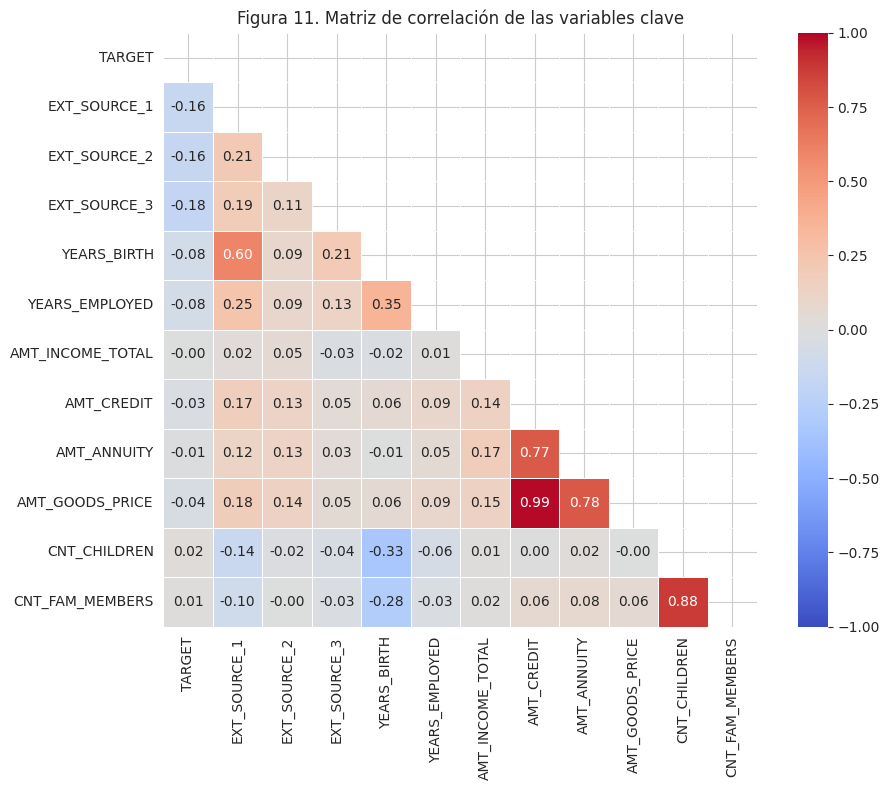

In [102]:
# Heatmap de un subconjunto: con las 122 variables no se entendería nada
subconjunto = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
               'YEARS_BIRTH', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL',
               'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
               'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

plt.figure(figsize=(10, 8))
matriz = eda_df[subconjunto].corr()
mascara = np.triu(np.ones_like(matriz, dtype=bool))   # ocultamos la mitad de arriba
sns.heatmap(matriz, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Figura 11. Matriz de correlación de las variables clave')
plt.tight_layout()
plt.show()

Interpretación del gráfico

Se confirma dos casos de **multicolinealidad severa:**
- `AMT_CREDIT` y`AMT_GOODS_PRICE` tienen una correlación de 0.99 prácticamente la misma variable.
- `CNT_CHILDREN` con `CNT_FAM_MEMBERS` llega a 0.88 (esperable,
ya que los hijos son parte de los miembros de familia).
- `AMT_ANNUITY` también está fuertemente asociada a ambas variables monetarias (0.77 y 0.78), consistente con que la cuota depende del monto financiado.

Un hallazgo **no anticipado** es la correlación entre `YEARS_BIRTH` y `EXT_SOURCE_1` (0.60), la más alta del heatmap fuera de los pares "redundantes por construcción". *No podemos confirmar la causa exacta sin conocer cómo se calcula el score, pero es un indicio de que la edad del solicitante podría ser uno de sus componentes.*

Por último, `AMT_INCOME_TOTAL` **no muestra correlación relevante con ninguna otra variable del subconjunto** (ni siquiera con `AMT_CREDIT`, 0.14), lo que refuerza la idea planteada en 3.3 de que el ingreso por sí solo aporta poco, y que un ratio crédito/ingreso podría capturar información que ninguna de las dos variables por separado logra explicar.

> Estos hallazgos son relevantes para más adelante ya que en una regresión logística, incluir `AMT_CREDIT` y `AMT_GOODS_PRICE` juntas (o `EXT_SOURCE_1` y `YEARS_BIRTH` juntas) probablemente genere coeficientes inestables o difíciles de interpretar, así que habrá que decidir si se elimina una de cada par, se combinan, o se aplican técnicas de regularización.

In [103]:
# Buscamos pares de variables que digan casi lo mismo
corr_abs = eda_df[num_cols].corr().abs()

# Nos quedamos solo con la mitad de arriba de la matriz para no contar dos veces cada par
triangulo = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pares = triangulo.stack().sort_values(ascending=False).reset_index()
pares.columns = ['variable_1', 'variable_2', 'correlación']

print(f"Pares con correlación mayor a 0.90: {(pares['correlación'] > 0.90).sum()}")
print("\nLos 15 más altos:")
display(pares.head(15).round(3))

Pares con correlación mayor a 0.90: 63

Los 15 más altos:


,variable_1,variable_2,correlación
0,FLAG_EMP_PHONE,SIN_EMPLEO_REGISTRADO,1.000
1,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.999
2,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998
3,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997
4,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997
5,ENTRANCES_AVG,ENTRANCES_MEDI,0.997
6,ELEVATORS_AVG,ELEVATORS_MEDI,0.996
7,COMMONAREA_AVG,COMMONAREA_MEDI,0.996
8,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995
9,APARTMENTS_AVG,APARTMENTS_MEDI,0.995


In [104]:
eda_df[['FLAG_EMP_PHONE', 'SIN_EMPLEO_REGISTRADO']].corr()

,FLAG_EMP_PHONE,SIN_EMPLEO_REGISTRADO
FLAG_EMP_PHONE,1.000000,-0.999848
SIN_EMPLEO_REGISTRADO,-0.999848,1.000000


La búsqueda sistemática encontró **63 pares de variables con correlación mayor a 0.90** → un número alto que confirma que buena parte del dataset contiene información duplicada.

El hallazgo más llamativo es `FLAG_EMP_PHONE` y `SIN_EMPLEO_REGISTRADO` (la variable creada en 3.0), con
una correlación de -0.9998 prácticamente una relación inversa perfecta → son, en la práctica, la misma variable con el signo invertido.

Confirmamos el signo negativo aparte porque la búsqueda de pares usa el valor absoluto de la correlación.
> Tiene sentido de negocio: **sin empleo registrado, no hay teléfono laboral que declarar.** Para más adelante, esto significa que no tiene sentido incluir ambas variables en el modelo → aportarían exactamente la misma información.

El resto del top 15 confirma, a mayor escala, la sospecha que habíamosdejado pendiente en la Figura 10:

→ 13 de los 15 pares más correlacionados pertenecen al bloque de vivienda, entre sus variantes `_AVG` y `_MEDI`
(`YEARS_BUILD`, `FLOORSMIN`, `FLOORSMAX`, `ENTRANCES`, `ELEVATORS`, `COMMONAREA`, `LIVINGAREA`, `APARTMENTS`, `BASEMENTAREA`, `YEARS_BEGINEXPLUATATION`, `LIVINGAPARTMENTS`, `NONLIVINGAREA`,`LANDAREA`) → todas con** correlaciones entre 0.99 y 0.998.**
>Esto no es un problema aislado de una variable, sino un **patrón sistemático en todo el bloque** → consistente con lo que ya habíamos anticipado en 2.4: probablemente alcance con conservar una sola variante estadística por atributo de vivienda más adelante

In [105]:
# Miramos si los tríos _AVG / _MODE / _MEDI del bloque de vivienda son redundantes
bases = ['APARTMENTS', 'YEARS_BEGINEXPLUATATION', 'FLOORSMAX', 'LIVINGAREA']

print("Correlación más baja dentro de cada trío:")
for b in bases:
    trio = [c for c in [f'{b}_AVG', f'{b}_MODE', f'{b}_MEDI']
            if c in eda_df.columns and eda_df[c].dtype != 'object']
    if len(trio) >= 2:
        m = eda_df[trio].corr()
        minima = m.where(~np.eye(len(m), dtype=bool)).min().min()
        print(f"  {b:<28} {minima:.3f}")

Correlación más baja dentro de cada trío:
  APARTMENTS                   0.974
  YEARS_BEGINEXPLUATATION      0.967
  FLOORSMAX                    0.986
  LIVINGAREA                   0.972


El chequeo confirma la sospecha para las cuatro bases probadas: en todos los casos, incluso el par menos correlacionado dentro de cada trío `_AVG` / `_MODE` / `_MEDI` **supera 0.96**
- `APARTMENTS`: 0.974
- `YEARS_BEGINEXPLUATATION`:0.967
- `FLOORSMAX`: 0.986
- `LIVINGAREA`: 0.972

Esto confirma que las **tres variantes estadísticas de cada atributo de vivienda son, en la práctica, redundantes entre sí** → no es un caso aislado de una sola variable, sino un
patrón que se repite en todo el bloque, consistente con lo detectado en el código anterior.

**Conclusión:** el análisis de correlación cumplió sus dos objetivos.
1. Respecto a la **relación con TARGET**, ninguna variable numérica individual tiene una correlación fuerte (máximo ≈0.18 en `EXT_SOURCE_3`), lo que confirma que el riesgo depende de una combinación de factores, no de unpredictor dominante.

2. Respecto a la **redundancia entre variables**, se detectaron 63 pares con correlación mayor a 0.90, concentrados mayoritariamente en el bloque de vivienda (variantes `_AVG` / `_MODE` / `_MEDI` de un mismo atributo), además de casos puntuales como `AMT_CREDIT` / `AMT_GOODS_PRICE` (0.99) y `FLAG_EMP_PHONE` / `SIN_EMPLEO_REGISTRADO` (-0.9998).

>Para más adelante, esto implica que gran parte del bloque de
vivienda podrá reducirse a una sola variante por atributo sin perder información relevante, y que los pares de variables monetarias y de empleo redundantes deberán resolverse antes de entrenar la regresión logística, para evitar coeficientes inestables.

### **3.5 Problemas de Calidad de Datos**

Aquí juntamos todo lo que fuimos encontrando a lo largo del análisis, para tenerlo ordenado antes de empezar la Evidencia 2.

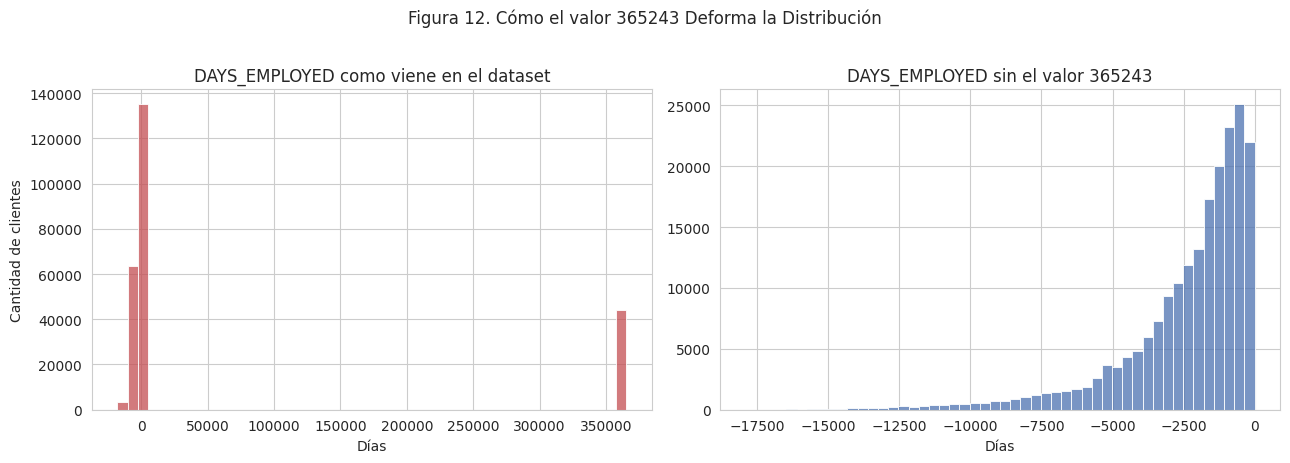

In [106]:
# 1. El valor raro de DAYS_EMPLOYED que ya vimos en 3.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(train_df['DAYS_EMPLOYED'], bins=50, ax=axes[0], color='#C44E52')
axes[0].set_title('DAYS_EMPLOYED como viene en el dataset')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Cantidad de clientes')

sns.histplot(train_df.loc[~mask_centinela, 'DAYS_EMPLOYED'], bins=50,
             ax=axes[1], color='#4C72B0')
axes[1].set_title('DAYS_EMPLOYED sin el valor 365243')
axes[1].set_xlabel('Días')
axes[1].set_ylabel('')

fig.suptitle('Figura 12. Cómo el valor 365243 Deforma la Distribución', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

- En el panel izquierdo (la variable tal como viene en el dataset), toda la información real de antigüedad laboral queda comprimida en una franja angosta cerca de cero,  **mientras** que una tercera barra aparece aislada en 365243 y separada del resto por un vacío de más de 300.000 días →  **confirmando que no es parte de la misma escala sino un código distinto** (ya identificado en 3.0: "sin empleo registrado", 18.0% de los casos).
- El panel derecho, sin ese valor, muestra la distribución real de la variable → en días negativos, tal como viene en el dataset original; la versión convertida a años positivos `YEARS_EMPLOYED`) ya se mostró en la Figura 3.

**Aclaración:** este valor debe tratarse como dato faltante (no como una antigüedad real de ~1000 años), conservando el indicador `SIN_EMPLEO_REGISTRADO` ya creado en 3.0, dado que resultó tener una relación fuerte con `FLAG_EMP_PHONE` (correlación -0.9998, ver 3.4).

In [107]:
# 2. Categorías que no aportan información o que parecen códigos de "sin dato"
print("CODE_GENDER:")
print(train_df['CODE_GENDER'].value_counts())
print()
print("NAME_FAMILY_STATUS:")
print(train_df['NAME_FAMILY_STATUS'].value_counts())
print()
n_xna = (train_df['ORGANIZATION_TYPE'] == 'XNA').sum()
print(f"ORGANIZATION_TYPE = 'XNA': {n_xna:,} ({n_xna/len(train_df)*100:.1f}%)")
print(f"Cantidad de Categorías de ORGANIZATION_TYPE: {train_df['ORGANIZATION_TYPE'].nunique()}")

# Comprobamos si son los mismos clientes que tenían el valor raro en DAYS_EMPLOYED
mismos = ((train_df['ORGANIZATION_TYPE'] == 'XNA') == mask_centinela).all()
print(f"¿Son los mismos clientes que 'sin empleo registrado'? {mismos}")

CODE_GENDER:
CODE_GENDER
F      161887
M       84119
XNA         2
Name: count, dtype: int64

NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Married                 157153
Single / not married     36359
Civil marriage           23812
Separated                15840
Widow                    12842
Unknown                      2
Name: count, dtype: int64

ORGANIZATION_TYPE = 'XNA': 44,143 (17.9%)
Cantidad de Categorías de ORGANIZATION_TYPE: 58
¿Son los mismos clientes que 'sin empleo registrado'? True


Tres variables categóricas usan un valor de texto para marcar información faltante o no declarada, en vez de un nulo real:
- `CODE_GENDER` tiene 2 casos con valor `'XNA'`
- `NAME_FAMILY_STATUS` tiene 2 casos con valor `'Unknown'` —ambos casos anecdóticos por su bajísima frecuencia, se
resolverán simplemente descartando esas filas mas adelante
- `ORGANIZATION_TYPE` tiene 44.143 casos (17.9%) con valor `'XNA'`, un
porcentaje mucho más relevante.

>Confirmamos que estos 44.143 casos de `ORGANIZATION_TYPE = 'XNA'` son exactamente los mismos clientes identificados como "sin empleo registrado" en `DAYS_EMPLOYED` (3.0).

Esto significa que ya van tres variables distintas del dataset codificando la misma señal → **un valor centinela
numérico** (`DAYS_EMPLOYED = 365243`), **un flag binario** (`FLAG_EMP_PHONE`, correlación -0.9998 con `SIN_EMPLEO_REGISTRADO`, ver 3.4) y ahora una **categoría de texto** (`ORGANIZATION_TYPE = 'XNA'`).

*Para más adelante,alcanzará con conservar el indicador `SIN_EMPLEO_REGISTRADO` ya creado en 3.0 y descartar esta redundancia en las otras variables.*

In [108]:
# 3. Valores extremos
extremos = ['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'OWN_CAR_AGE',
            'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE']

tabla = train_df[extremos].describe(percentiles=[0.5, 0.95, 0.99]).T.round(2)
tabla['max/p99'] = (tabla['max'] / tabla['99%']).round(1)
display(tabla)

print("\nClientes con ingreso declarado mayor a 5.000.000:")
display(train_df.loc[train_df['AMT_INCOME_TOTAL'] > 5_000_000,
                     ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'NAME_INCOME_TYPE', 'TARGET']])

,count,mean,std,min,50%,95%,99%,max,max/p99
AMT_INCOME_TOTAL,246008.0,168853.18,258960.63,25650.0,147600.0,337500.0,472500.0,117000000.0,247.6
CNT_CHILDREN,246008.0,0.42,0.72,0.0,0.0,2.0,3.0,19.0,6.3
OWN_CAR_AGE,83590.0,12.06,11.91,0.0,9.0,30.0,64.0,91.0,1.4
DEF_30_CNT_SOCIAL_CIRCLE,245197.0,0.14,0.45,0.0,0.0,1.0,2.0,34.0,17.0
OBS_30_CNT_SOCIAL_CIRCLE,245197.0,1.42,2.42,0.0,0.0,6.0,10.0,348.0,34.8



Clientes con ingreso declarado mayor a 5.000.000:


,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_INCOME_TYPE,TARGET
12840,117000000.0,562491.0,Working,1
203693,18000090.0,675000.0,Commercial associate,0
131127,6750000.0,790830.0,Working,0
77768,9000000.0,1431531.0,Working,0


El ratio entre el máximo y el percentil 99 (`max/p99`) permite distinguir entre variables con un **outlier puntual extremo y variables donde el valor más alto es simplemente el borde de una cola larga pero razonable.**

- `AMT_INCOME_TOTAL` tiene el ratio más alto de lejos (247.6): su máximo es 247 veces el percentil 99, evidencia de que se trata de un caso completamente fuera de escala, no de una cola normal.
- `OBS_30_CNT_SOCIAL_CIRCLE`y `DEF_30_CNT_SOCIAL_CIRCLE` también muestran ratios altos (34.8 y 17.0). Las variables refieren al entorno social del cliente que también son clientes de la entidad. `OBS_30` indica cuántas personas de ese entorno pudieron observarse, y `DEF_30` indica cuántas de ellas incurrieron en un atraso de pago de
30 días o más. Las variantes `_60` aplican el mismo criterio con un atraso de 60 días. En conjunto, buscan capturar si el entorno cercano del solicitante tiene antecedentes de
incumplimiento.

- En el otro extremo, `OWN_CAR_AGE` tiene un ratio de apenas 1.4 → su máximo (91 años) está cerca del percentil 99 (64), lo que indica que no hay un outlier puntual ahí, **solo el extremo superior de una distribución normal**; no necesitaría el mismo tratamiento que las demás.

Al revisar en detalle los cuatro clientes con ingreso declarado mayor a 5.000.000, **se confirma el mismo patrón que en 3.3:** los tres casos con ingresos altos pero dentro de un orden de magnitud razonable (18.000.090, 9.000.000 y 6.750.000) tienen `TARGET=0`, mientras que el caso verdaderamente extremo (117.000.000 → casi 15 veces el siguiente más alto de la lista) es justamente el que tiene `TARGET=1`.
> Esto refuerza la hipótesis de que **este valor puntual es un error de carga** (posiblemente un cero de más) y **no un ingreso real,** y que su tratamiento para más adelante debería ser
distinto al de los otros tres casos altos pero plausibles.

In [109]:
# 4. Variables que tienen siempre (o casi siempre) el mismo valor
todas_num = eda_df.select_dtypes(include='number').columns

constantes = [c for c in todas_num if eda_df[c].nunique(dropna=True) <= 1]
print(f"Variables con un solo valor posible: {constantes}")

casi_constantes = {}
for c in todas_num:
    vc = eda_df[c].value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] > 0.999:
        casi_constantes[c] = round(vc.iloc[0] * 100, 3)

print(f"\nVariables donde un solo valor cubre más del 99.9% de los casos: {len(casi_constantes)}")
display(pd.Series(casi_constantes, name='% del valor dominante')
          .sort_values(ascending=False).to_frame())

Variables con un solo valor posible: []

Variables donde un solo valor cubre más del 99.9% de los casos: 10


,% del valor dominante
FLAG_MOBIL,100.000
FLAG_DOCUMENT_12,100.000
FLAG_DOCUMENT_10,99.998
FLAG_DOCUMENT_2,99.996
FLAG_DOCUMENT_4,99.991
FLAG_DOCUMENT_7,99.981
FLAG_DOCUMENT_17,99.975
FLAG_DOCUMENT_21,99.968
FLAG_DOCUMENT_20,99.950
FLAG_DOCUMENT_19,99.939


Ninguna variable numérica tiene un único valor posible en todo el dataset, **pero 10 variables tienen un valor que cubre más del 99.9% de los casos** →  todas ellas `FLAG_MOBIL` o variantes de `FLAG_DOCUMENT_*` (documentos presentados durante el trámite). `FLAG_MOBIL` está en 100.000% y varios
`FLAG_DOCUMENT_*` rozan ese mismo valor (`FLAG_DOCUMENT_12`: 100.000%, `FLAG_DOCUMENT_10`: 99.998%).

>Esto es coherente con lo que ya se había identificado en 2.4: **son documentos que casi todos los solicitantes presentan (o casi ninguno) como parte estándar del trámite**, así que la variable apenas varía entre clientes.

Al no haber prácticamente variación, **no pueden aportar poder predictivo a un modelo** independientemente de si el cliente cae en default o no, casi todos comparten el mismo valor. Para más adelante consideramos que estas 10 variables son candidatas directas a eliminarse antes de entrenar el modelo, junto con la reducción de variables redundantes del bloque de vivienda identificada en 3.4.

**Síntesis de 3.5 ordenada por prioridad** -  de mayor a menor urgencia para más adelante:

1. El **valor centinela** de `DAYS_EMPLOYED`, que además aparece triplicado en el dataset a través de `FLAG_EMP_PHONE` y `ORGANIZATION_TYPE = 'XNA'`
2. Los **nulos** de los `EXT_SOURCE_*`, por ser las variables con mayor poder predictivo pero también con más faltantes
3. La **redundancia masiva del bloque de vivienda**, confirmada en 3.4
4. La **asimetría de las variables monetarias**,
con el caso extremo de `AMT_INCOME_TOTAL` cayendo específicamente en el grupo de default
5. Las **variables casi constantes** (`FLAG_DOCUMENT_*`),
que pueden eliminarse directamente sin mayor análisis.
6. Los **casos anecdóticos** (`CODE_GENDER`/`NAME_FAMILY_STATUS` con 2 registros cada uno) y las **categorías minoritarias de las variables nominales** son ajustes menores que también deberán resolverse, pero con menor impacto esperado en el modelo final.

## **4. Conclusiones del EDA**

Luego de todo el proceso que llevamos a cabo pudimos responder las siguientes preguntas:

### **4.1 ¿Existe desbalance entre clientes buenos y malos?**

Sí, y es marcado: de los 246.008 clientes del conjunto de entrenamiento, el 91.93% cumple con sus pagos y solo el 8.07% cae en incumplimiento. Es decir, **por cada cliente que incumple, hay aproximadamente 11 que cumplen.**

Esto nos obliga a tomar algunas decisiones para más adelante:

No podemos medir si el modelo es bueno solo con el porcentaje de aciertos totales (accuracy).
>Si el modelo predijera "este cliente va a pagar" para todos los casos, acertaría el 91.93% de las veces sin haber aprendido nada, y fallaría justo en detectar a quienes no pagan, **que es lo que buscamos lograr.**

Por eso, en la etapa de evaluación del modelo vamos a necesitar otras formas de medir su desempeño, enfocadas en qué tan bien detecta los casos de incumplimiento y no solo en el porcentaje de aciertos general.

Al entrenar el modelo, también vamos a tener que ayudarlo a prestarle más atención a los casos de default, porque son pocos y podría tender a ignorarlos. Y el punto de corte para decidir "este cliente es riesgoso" probablemente no deba ser el 50%: como planteamos en la Sección 1, para la entidad es más costoso otorgar crédito a alguien que no va a pagar que rechazar a alguien que sí iba a pagar. Por eso ese punto de corte conviene ajustarlo.

*Aclaramos que esta comparación de costos es una idea general: no contamos con cifras reales de una entidad financiera para calcularlo con precisión.*

También hay que tener en cuenta algo que ya señalamos en la Sección 1: ese 8% no es la tasa de incumplimiento de cualquiera que solicite un crédito, sino solo de quienes **ya fueron aprobados** por la entidad.

>El modelo se entrena sobre un grupo de personas que ya pasó un filtro previo.

### **4.2 ¿Qué variables parecen relevantes?**

Encontramos cuatro grupos de variables, ordenados de mayor a menor aporte
para distinguir entre clientes que cumplen y clientes en default:

- Los **scores externos** (`EXT_SOURCE_1/2/3`, puntajes calculados por fuentes externas a la entidad, similares en su función a un puntaje de crédito) son los que mejor separan ambos grupos: los clientes con puntaje bajo son los que más caen en default (Figuras 6 y 10).

- La **edad y la antigüedad laboral** muestran una relación clara: cuanto más joven es el cliente y menor su antigüedad laboral, mayor el riesgo de incumplimiento (Figura 7).

- El **perfil socioeconómico** (nivel educativo, tipo de ingreso, ocupación) muestra diferencias considerables: hay categorías con hasta 6 veces más riesgo de default que otras (Figuras 8 y 9).

- Las **variables monetarias** (monto del crédito, cuota, ingreso) por sí solas aportan poco para distinguir entre ambos grupos. Es probable que resulten más útiles combinadas, por ejemplo calculando qué proporción del ingreso representa la cuota.

Rescatamos dos hallazgos importantes:
>**Ninguna variable, por sí sola, tiene una relación fuerte con el default** (la más fuerte es débil) → el modelo va a necesitar combinar varias variables para predecir bien, no alcanza con mirar una sola.

> La **variable más útil** que encontramos (`EXT_SOURCE_1`) es también la que **más datos le faltan** →
es un problema que vamos a tener que resolver en la próxima entrega.

### **4.3 ¿Qué problemas deberán resolverse antes de entrenar un modelo?**

Los que identificamos en la sección 3.5, que se pueden agrupar en tres tipos de trabajo:

1. **Limpiar los datos** →  sacar el valor "raro" de la antigüedad laboral (guardando la información de que ese cliente no tiene empleo registrado), decidir qué hacer con las variables de vivienda (que tienen muchos datos faltantes), definir cómo completar los datos faltantes de los scores externos y ordenar algunas categorías mal cargadas.

2. **Transformar los datos** →  las variables de dinero necesitan un ajuste matemático (transformación logarítmica) y todas las variables numéricas y van a necesitar reescalarse, además de convertir las variables de texto (categorías) a números. Esto lo pide el tipo de modelo que vamos a usar
(regresión logística).

3. **Reducir la cantidad de variables** → sacar las que casi no cambian entre clientes (no aportan información) y las que están repitiendo la misma información que otra.

### **4.4 Qué nos llevamos para la Evidencia 2**

Además de resolver esos problemas, el EDA nos dejó tres ideas para explorar más adelante:

1. Construir **indicadores de capacidad de pago**, como la cuota dividida por el ingreso, ya que los montos por separado no mostraron buen poder de separación.

2. Agregar **columnas que indiquen si un dato faltaba o no**, sobre todo en los scores externos y en las variables de vivienda, dado que la ausencia del dato puede en sí misma aportar información sobre el cliente.

3. Evaluar alguna forma de **combinar los tres scores externos** en uno solo, para no perder esa información aunque a algún cliente le falte uno de los tres.

**Aclaración sobre el alcance del proyecto**
> Este análisis es un ejercicio académico. El dataset corresponde a Home Credit (Kaggle, 2018), de un mercado y un período que no conocemos, y el "Área de Riesgo Financiero" mencionado como stakeholder es un interlocutor simulado a los fines del proyecto. Todo lo que decimos sobre "la entidad" es una interpretación de lo que muestran los datos, no información que tengamos del negocioreal.

---


#                                     **Evidencia 2**


---

## **5. Limpieza y Preparación de Datos**

Los problemas de calidad de datos identificados en la Evidencia 1 (sección 3.5) son el punto de partida de esta etapa. A continuación se aplican, sobre una copia de trabajo del conjunto de entrenamiento ('train_clean'), las correcciones necesarias para dejar el dataset en condiciones de alimentar un modelo predictivo. En cada punto documentamos el tratamiento de valores faltantes, el manejo de variables problemáticas y la justificación de la decisión tomada.

In [110]:
# Partimos de train_df (el dataset "real" de la Evidencia 1) y creamos train_clean,
# que va a ser la versión que llevamos adelante durante todo el proyecto.
train_clean = train_df.copy()

print(f"Filas: {train_clean.shape[0]}, Columnas: {train_clean.shape[1]}")

Filas: 246008, Columnas: 122




### **5.1 Valor centinela en DAYS_EMPLOYED**

La variable 'DAYS_EMPLOYES'contiene un valor centinela (365243) que, expresado en años, equivale a casi mil años de antigüedad laboral, una cifra imposible. Como se documentó en el EDA (sección 3.0), este valor no corresponde a un error aleatorio sino a un código utilizado para señalar clientes sin empleo registrado (jubilados o desempleados), presente en el 18% de los casos.

>Dejar este valor mezclado con los datos reales distorsiona cualquier estadístico calculado sobre la variable (el promedio de antigüedad laboral llegaba a 174 años).

*No se optó por eliminar los registros afectados, dado que representan una porción demasiado grande del dataset (18%) como para descartarla sin pérdida de información.*

**Se aplicó entonces un tratamiento en dos pasos:**
1. Se conservó el indicador binario 'SIN_EMPLEO_REGISTRADO', ya construido en el EDA, que resultó tener valor predictivo propio: el grupo sin empleo registrado presenta una tasa de default menor (5.4%) que el resto (8.7%), probablemente por tratarse en su mayoría de jubilados con ingreso estable.
2. El valor centinela se reemplazó por un dato faltante (NaN) real en 'YEARS_EMPLOYED', en lugar de imputarlo directamente, así evitamos perder la señal que ya aporta el indicador creado en el paso anterior.




In [111]:
# Igual que en 3.0 del EDA, pero ahora de forma definitiva sobre train_clean

CENTINELA = 365243

# Guardamos el indicador ANTES de tocar la variable (ya lo habíamos validado en el EDA)
train_clean['SIN_EMPLEO_REGISTRADO'] = (train_clean['DAYS_EMPLOYED'] == CENTINELA).astype(int)

# Convertimos días a años
train_clean['YEARS_BIRTH'] = (-train_clean['DAYS_BIRTH'] / 365.25).round(1)
train_clean['YEARS_EMPLOYED'] = (-train_clean['DAYS_EMPLOYED'] / 365.25).round(1)

# El valor centinela pasa a NaN de forma DEFINITIVA
train_clean.loc[train_clean['SIN_EMPLEO_REGISTRADO'] == 1, 'YEARS_EMPLOYED'] = np.nan

print(f"SIN_EMPLEO_REGISTRADO=1: {train_clean['SIN_EMPLEO_REGISTRADO'].sum():,} "
      f"({train_clean['SIN_EMPLEO_REGISTRADO'].mean()*100:.1f}%)")
print(f"Nulos en YEARS_EMPLOYED: {train_clean['YEARS_EMPLOYED'].isnull().sum():,}")

SIN_EMPLEO_REGISTRADO=1: 44,143 (17.9%)
Nulos en YEARS_EMPLOYED: 44,143


### **5.2 Eliminación de variables redundantes: FLAG_EMP_PHONE y ORGANIZATION_TYPE**

El análisis de correlaciones de la sección 3.4 mostró que la variable 'FLAG_EMP_PHONE' (presencia de teléfono laboral declarado) tiene una correlación de -0.9998 con 'SIN_EMPLEO_REGISTRADO': ambas codifican, en la práctica, la misma señal.
>Mantener dos variables que representan la misma información introduce inestabilidad en los coeficientes de una regresión logística, ya que el modelo no puede distinguir cuál de ellas explica realmente el riesgo.

Por este motivo, se eliminó 'FLAG_EMP_PHONE' y se conservó únicamente 'SIN_EMPLEO_REGISTRADO', por ser la variable de nombre
más interpretable.

El caso de 'ORGANIZATION_TYPE' es distinto. Lo que se confirmó en la sección 3.5 es que su categoría 'XNA' corresponde exactamente a los mismos clientes sin empleo registrado, no que toda la variable sea redundante: sus otras 57 categorías describen el sector o rubro de actividad del empleador (por ejemplo, 'Business Entity Type 3', 'Self-employed', 'Trade: type 7') para el 82% de los clientes que sí tienen empleo, información que 'SIN_EMPLEO_REGISTRADO' no captura. Se decidió eliminarla de todos modos, pero por un motivo distinto:
> Su alta cardinalidad (58 categorías) generaría una gran cantidad de columnas al codificarla, lo que excede el alcance de esta etapa del proyecto. Se prioriza así la parsimonia del modelo baseline por sobre una posible ganancia marginal de información, quedando como una variable a reconsiderar en una iteración futura del modelo.


In [112]:
# Confirmado en 3.4/3.5: FLAG_EMP_PHONE tiene correlacion -0.9998 con SIN_EMPLEO_REGISTRADO,
# y ORGANIZATION_TYPE='XNA' son los mismos clientes. Nos alcanza con conservar
# SIN_EMPLEO_REGISTRADO y descartar las otras dos fuentes de la misma señal.

train_clean = train_clean.drop(columns=['FLAG_EMP_PHONE', 'ORGANIZATION_TYPE'])

print("Columnas eliminadas: FLAG_EMP_PHONE, ORGANIZATION_TYPE")
print(f"Columnas restantes: {train_clean.shape[1]}")
print("--- Verificación de ORGANIZATION_TYPE ---")
print(train_df['ORGANIZATION_TYPE'].nunique())
print(train_df['ORGANIZATION_TYPE'].value_counts(normalize=True))

Columnas eliminadas: FLAG_EMP_PHONE, ORGANIZATION_TYPE
Columnas restantes: 123
--- Verificación de ORGANIZATION_TYPE ---
58
ORGANIZATION_TYPE
Business Entity Type 3    0.221277
XNA                       0.179437
Self-employed             0.124272
Other                     0.054092
Medicine                  0.036523
Business Entity Type 2    0.034271
Government                0.033905
School                    0.029182
Trade: type 7             0.025463
Kindergarten              0.022568
Construction              0.021946
Business Entity Type 1    0.019593
Transport: type 4         0.017524
Trade: type 3             0.011382
Industry: type 9          0.011057
Industry: type 3          0.010772
Security                  0.010597
Housing                   0.009638
Industry: type 11         0.008817
Military                  0.008589
Bank                      0.008130
Agriculture               0.008028
Police                    0.007565
Transport: type 2         0.007191
Postal            

### **5.3 Reducción del bloque de vivienda (47 variables)**


El dataset incluye **47 columnas que describen características de la vivienda del cliente** (superficie, cantidad de ascensores, antigüedad del edificio, entre otras). De estas, 42 corresponden a 14 atributos que se repiten en tres variantes estadísticas: '_AVG' (promedio), '_MODE' (moda)
y '_MEDI' (mediana).
> El análisis de correlación (sección 3.4) confirmó que, dentro de cada trío, la correlación mínima supera 0.96, es decir, las tres variantes son redundantes entre sí.

**Conservar las tres incrementa la dimensionalidad del dataset sin aportar información adicional, por lo que se mantuvo una sola variante por atributo** ('_MEDI', por ser más robusta ante valores extremos que '_AVG', aplicando el mismo criterio utilizado en el tratamiento de 'AMT_INCOME_TOTAL', sección 5.6) y se descartaron las otras dos.

Las 5 columnas restantes del bloque ('FONDKAPREMONT_MODE',
'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE',
'EMERGENCYSTATE_MODE') no siguen este patrón de trío:
 > Son variables categóricas sueltas (tipo de vivienda, material de las paredes, estado de emergencia del edificio, entre otras) sin una variante numérica que las duplique, por lo que no son redundantes en el mismo sentido que las anteriores.

**Se optó por eliminarlas de todas formas**, dado que pertenecen al segmento del dataset con mayor proporción de valores faltantes (hasta 70% de nulos, ver sección 2.5) y su tratamiento (imputación de
categóricas con alta nulidad) excede el alcance de este modelo baseline.
*Quedan como candidatas a revisar en una futura iteración del proyecto.*


In [113]:
### 5.3 Reducción del bloque de vivienda (47 variables)

# Confirmado en 3.4: las variantes _AVG / _MODE / _MEDI de cada atributo de
# vivienda tienen correlación >0.96 entre sí (redundantes). Nos quedamos con
# la variante _MEDI (mediana) de cada atributo, más robusta ante outliers,
# consistente con el mismo criterio usado en AMT_INCOME_TOTAL (5.6).

# Nota: el filtro por texto (_AVG/_MODE) también elimina 5 columnas categóricas
# sueltas sin trío (FONDKAPREMONT_MODE, HOUSETYPE_MODE, TOTALAREA_MODE,
# WALLSMATERIAL_MODE, EMERGENCYSTATE_MODE). No son redundantes por correlación,
# se eliminan por su alta nulidad (hasta 70%, ver 2.5) y quedan fuera del
# alcance de este baseline.

cols_vivienda = bloques_variables["6. Características de la vivienda"]
cols_to_drop = [c for c in cols_vivienda if c.endswith('_AVG') or c.endswith('_MODE')]

# Filter the columns to drop to only those that are actually present in train_clean
cols_to_drop_present = [col for col in cols_to_drop if col in train_clean.columns]

print(f"Variables del bloque vivienda identificadas: {len(cols_vivienda)}")
print(f"Variables _AVG/_MODE a eliminar (presentes en train_clean): {len(cols_to_drop_present)}")

if cols_to_drop_present: # Only attempt to drop if there are columns to drop
    train_clean = train_clean.drop(columns=cols_to_drop_present)
else:
    print("Advertencia: Ninguna de las variables _AVG/_MODE a eliminar se encontró en train_clean. Es posible que ya hayan sido eliminadas en un paso anterior.")


print(f"Columnas restantes: {train_clean.shape[1]}")

Variables del bloque vivienda identificadas: 47
Variables _AVG/_MODE a eliminar (presentes en train_clean): 33
Columnas restantes: 90


### **5.4 Categorías anecdóticas: CODE_GENDER='XNA' y NAME_FAMILY_STATUS='Unknown'**

Las variables 'CODE_GENDER' y 'NAME_FAMILY_STATUS' presentan, cada una, dos registros con un valor no informativo ('XNA' y 'Unknown', respectivamente).

>Dado el volumen extremadamente bajo de estos casos (2 registros por variable, 4 en total sobre 246.008 registros), no se justifica una estrategia de imputación: no hay evidencia suficiente para inferir con algún criterio razonable qué valor correspondería a cada caso.

Se eliminó directamente estas cuatro filas del conjunto de datos.

*Al ser una fracción tan chica del dataset (0.0016%), eliminarlas no introduce ningún sesgo relevante.*




In [114]:
filas_antes = train_clean.shape[0]

train_clean = train_clean[
    (train_clean['CODE_GENDER'] != 'XNA') &
    (train_clean['NAME_FAMILY_STATUS'] != 'Unknown')
]

print(f"Filas eliminadas: {filas_antes - train_clean.shape[0]}")
print(f"Filas restantes: {train_clean.shape[0]:,}")

Filas eliminadas: 4
Filas restantes: 246,004


### **5.5 Variables casi constantes (FLAG_DOCUMENT_ y FLAG_MOBIL)**

Un subconjunto de variables binarias, correspondientes a distintos documentos presentados durante el trámite ('FLAG_DOCUMENT_2'), (FLAG_DOCUMENT_3'), entre otras) y (FLAG_MOBIL), presenta el mismo valor en más del 99.9% de los registros.

>A diferencia de los problemas anteriores, aquí no hay valores faltantes: el dato está completo, pero prácticamente no varía entre clientes.

Una variable sin variabilidad no puede aportar poder predictivo, dado que no permite diferenciar entre clientes que cumplen y clientes en default.
Se identificaron 10 variables con esta característica (FLAG_MOBIL y 9 variantes de FLAG_DOCUMENT_*), ya relevadas en la Sección 3.5 del EDA, y
se eliminaron del dataset.


In [115]:


todas_num = train_clean.select_dtypes(include='number').columns
casi_constantes = []
for c in todas_num:
    vc = train_clean[c].value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] > 0.999:
        casi_constantes.append(c)

print(f"Variables casi constantes a eliminar: {len(casi_constantes)}")
print(casi_constantes)

train_clean = train_clean.drop(columns=casi_constantes)
print(f"Columnas restantes: {train_clean.shape[1]}")

Variables casi constantes a eliminar: 10
['FLAG_MOBIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']
Columnas restantes: 80


### **5.6 Tratamiento del valor extremo en AMT_INCOME_TOTAL**

AMT_INCOME_TOTAL presenta un valor de 117.000.000, aproximadamente 15 veces superior al segundo ingreso más alto registrado en el dataset, lo que sugiere un error de carga.
> Este tipo de valores extremos afecta de forma desproporcionada al promedio de la variable y
puede desestabilizar el entrenamiento de un modelo de regresión logística, sensible a la
escala de sus variables de entrada.

A diferencia del criterio aplicado en la sección 5.4, en este caso **no se eliminó el registro completo, ya que corresponde a un cliente que efectivamente
presenta incumplimiento (TARGET=1),** perteneciente a la clase minoritaria del dataset (8.07%
del total). *Eliminar esta observación implicaría una pérdida evitable de información sobre el
segmento de mayor interés para el proyecto.*


Se aplicó una **técnica de capping (recorte):** todo
valor por encima del percentil 99 de la distribución (472.500) se reemplaza por ese límite. Esto
afecta a 2.416 registros (0.98% del dataset), no solo al caso extremo de 117.000.000, **se optó por este criterio más amplio en lugar de tratar únicamente el outlier puntual, porque la variable ya mostraba asimetría considerable en el resto de su distribución** (skewness de 375.13, ver Sección 3.2), y el capping general reduce la sensibilidad del modelo a toda la cola superior, no solo al caso más extremo.


In [116]:


p99_income = train_clean['AMT_INCOME_TOTAL'].quantile(0.99)
print(f"P99 de AMT_INCOME_TOTAL: {p99_income:,.0f}")

n_afectados = (train_clean['AMT_INCOME_TOTAL'] > p99_income).sum()
print(f"Registros por encima del P99 (se van a capear): {n_afectados}")

train_clean['AMT_INCOME_TOTAL'] = train_clean['AMT_INCOME_TOTAL'].clip(upper=p99_income)

P99 de AMT_INCOME_TOTAL: 472,500
Registros por encima del P99 (se van a capear): 2416


### **5.7 Exclusión de la variable edad por criterio de equidad (Fairness)**

El EDA (sección 3.3.1) confirmó que 'YEARS_BIRTH' tiene una relación clara e inversa con el riesgo de incumplimiento:
>Los clientes más jóvenes presentan una tasa de default de hasta 2.5 veces la de los clientes de mayor edad.

Decidimos no utilizar la edad como variable predictora directa: esta decisión de "crédito justo" (fair lending) es usada en la práctica de la industria crediticia, donde las decisiones de otorgamiento deberían basarse en el mérito individual del
solicitante y no en atributos demográficos.

>Un modelo entrenado con esta variable podría penalizar sistemáticamente a clientes jóvenes solventes por pertenecer a ese grupo etario, en lugar de evaluarlos por su comportamiento financiero individual.

'YEARS_BIRTH'no se descarta del proyecto: **se separa en un conjunto aparte ('train_audit_edad'),** excluida también de cualquier paso de imputación posterior (sección 5.8) para evitar que su influencia se filtre de forma indirecta a través de otra variable. Esta reserva es una preparación para la Evidencia 3, donde se plantea evaluar si el modelo, aun sin haber "visto" la edad durante el entrenamiento, termina produciendo predicciones sistemáticamente distintas entre clientes jóvenes y adultos.

In [117]:
# Se reserva la edad en un conjunto separado, exclusivamente para auditoría
# de equidad en la Evidencia 3. No se usa para entrenar ni para imputar.
train_audit_edad = train_clean[['YEARS_BIRTH']].copy()

train_clean = train_clean.drop(columns=['YEARS_BIRTH'])

print("YEARS_BIRTH removida de train_clean y reservada en train_audit_edad "
      f"({train_audit_edad.shape[0]:,} registros) para la auditoría de fairness en Evidencia 3.")

YEARS_BIRTH removida de train_clean y reservada en train_audit_edad (246,004 registros) para la auditoría de fairness en Evidencia 3.


###**5.8 Imputación de EXT_SOURCE_1/2/3 mediante Iterative Imputer (MICE)**

Los tres scores externos son las variables con mayor correlación con'TARGET' de todo el dataset (sección 3.4), pero presentan distintos niveles de valores faltantes:
* 56.34% en 'EXT_SOURCE_1'
* 19.84% en 'EXT_SOURCE_3'  
* 0.22% en 'EXT_SOURCE_2'

*Dado su alto poder predictivo, se descartó la opción de eliminarlas.*

Se evaluó inicialmente una imputación por mediana, pero se descartó por debilitar la variabilidad de la variable de mayor poder predictivo del dataset. **Se optó en cambio por Iterative Imputer (MICE), que estima cada valor faltante a partir de un modelo de regresión ajustado sobre otras variables del cliente.**

Como predictoras se utilizaron los otros dos
scores externos y 'YEARS_EMPLOYED', se excluyó deliberadamente 'YEARS_BIRT'`, en línea con la decisión de la sección 5.7 de **mantener la
edad completamente fuera del pipeline de modelado.**

>'YEARS_EMPLOYED' participa únicamente como variable predictora del modelo de imputación: sus propios valores faltantes no se sobreescriben, y se
mantienen como NaN de acuerdo con el criterio fijado en la sección 5.1.

Se conservó, además, un indicador binario ('_FALTABA') para cada score, dado que la ausencia del dato ya demostró tener relación con 'TARGET' en 'EXT_SOURCE_1' y 'EXT_SOURCE_3' (sección 3.3.1).

In [118]:
### 5.8 Imputación de EXT_SOURCE_1/2/3 mediante Iterative Imputer (MICE)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    train_clean[f'{col}_FALTABA'] = train_clean[col].isnull().astype(int)

# YEARS_BIRTH se excluye deliberadamente (ver 5.7): la imputación no debe
# incorporar la edad ni siquiera de forma indirecta.
cols_predictoras_imputacion = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'YEARS_EMPLOYED'
]

imputer_ext_source = IterativeImputer(random_state=42, max_iter=10)
valores_imputados = imputer_ext_source.fit_transform(train_clean[cols_predictoras_imputacion])

# YEARS_EMPLOYED se usa como predictora del modelo de imputación, pero NO
# se sobreescribe: sus nulos son información válida en sí misma, ya
# capturada en SIN_EMPLEO_REGISTRADO (Sección 5.1). Por eso solo tomamos
# las primeras 3 columnas de la salida (los scores externos).
train_clean[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']] = valores_imputados[:, :3]

# Los scores externos son, por definición, valores entre 0 y 1 (ver 3.1).
# IterativeImputer puede extrapolar fuera de ese rango al imputar; lo
# acotamos para preservar la interpretación original de la variable.
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    train_clean[col] = train_clean[col].clip(lower=0, upper=1)

print("Nulos restantes en EXT_SOURCE_*:")
print(train_clean[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().sum())
print(f"\nNulos en YEARS_EMPLOYED (deben preservarse, ver 5.1): "
      f"{train_clean['YEARS_EMPLOYED'].isnull().sum():,}")

Nulos restantes en EXT_SOURCE_*:
EXT_SOURCE_1    0
EXT_SOURCE_2    0
EXT_SOURCE_3    0
dtype: int64

Nulos en YEARS_EMPLOYED (deben preservarse, ver 5.1): 44,143


### **5.9 Nulos restantes en el bloque de vivienda**

Tras conservar únicamente la variante '_MEDI' de cada atributo de vivienda (sección 5.3), persisten valores faltantes en ese subconjunto de variables. Como se documentó en la sección 2.5, este patrón no es aleatorio:
>La información de vivienda depende de que el solicitante la haya declarado (por ejemplo, no aplica si alquila), por lo que el faltante es de tipo estructural.

Dado que las 14 variables del bloque comparten el mismo origen de faltante, no se justifica crear un indicador binario por cada una (lo que introduciría nuevamente redundancia, el mismo problema resuelto en 5.3). Se optó por un único indicador consolidado, 'SIN_DATO_VIVIENDA', que resume si el cliente presenta información de vivienda declarada o no. Los valores faltantes de las variables '_MEDI' se imputaron luego con la mediana de cada una, calculada sobre 'train_clean'.

In [119]:
### 5.9 Bloque vivienda: las variables restantes son las _MEDI (ver 5.3)

cols_vivienda_medi = [c for c in train_clean.columns if c.endswith('_MEDI')]

# Un solo flag consolidado: alcanza con revisar si falta el primero de la lista,
# ya que el faltante es estructural y compartido por todo el bloque (ver 2.5)
train_clean['SIN_DATO_VIVIENDA'] = train_clean[cols_vivienda_medi[0]].isnull().astype(int)

print(f"SIN_DATO_VIVIENDA=1: {train_clean['SIN_DATO_VIVIENDA'].sum():,} "
      f"({train_clean['SIN_DATO_VIVIENDA'].mean()*100:.1f}%)")

# Imputación con mediana, columna por columna
for col in cols_vivienda_medi:
    train_clean[col] = train_clean[col].fillna(train_clean[col].median())

print(f"Nulos restantes en bloque vivienda: {train_clean[cols_vivienda_medi].isnull().sum().sum()}")

SIN_DATO_VIVIENDA=1: 124,731 (50.7%)
Nulos restantes en bloque vivienda: 0


In [120]:
print(cols_vivienda_medi)

['APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI']


### **5.10 OCCUPATION_TYPE y OWN_CAR_AGE**

'OCCUPATION_TYPE presenta 31% de valores faltantes, correspondientes en su mayoría a clientes sin ocupación activa (jubilados, según se observó en la sección 3.3.2).
>Al tratarse de una variable categórica donde la ausencia del dato es en sí misma informativa y no un error, se optó por convertir los valores faltantes en una categoría explícita ("Sin dato"), en lugar de imputarlos con la categoría más frecuente, lo que ocultaría esa distinción.

'OWN_CAR_AGE' presenta 66% de valores faltantes, un porcentaje que coincide con la proporción de clientes que no poseen vehículo ('FLAG_OWN_CAR = 'N'', ver sección 3.1). Dado que esa condición ya está representada explícitamente por 'LAG_OWN_CAR', no se creó un indicador adicional: se consideró redundante. Los valores faltantes se completaron con 0, interpretándose como "no aplica antigüedad de vehículo".

In [121]:


# OCCUPATION_TYPE: la ausencia es informativa, se conserva como categoría explícita
train_clean['OCCUPATION_TYPE'] = train_clean['OCCUPATION_TYPE'].fillna('Sin_dato')

# OWN_CAR_AGE: el faltante ya está representado por FLAG_OWN_CAR, se imputa con 0
train_clean['OWN_CAR_AGE'] = train_clean['OWN_CAR_AGE'].fillna(0)

print("Nulos en OCCUPATION_TYPE:", train_clean['OCCUPATION_TYPE'].isnull().sum())
print("Nulos en OWN_CAR_AGE:", train_clean['OWN_CAR_AGE'].isnull().sum())

Nulos en OCCUPATION_TYPE: 0
Nulos en OWN_CAR_AGE: 0


### 5.11 Verificación final y tratamiento de nulos residuales

Los pasos anteriores resolvieron los nulos de los bloques con mayor volumen o mayor
relevancia predictiva (vivienda, scores externos, ocupación). Antes de avanzar a la
Ingeniería de Características, se realiza una verificación final para confirmar que
no queden valores faltantes sin tratar en ninguna otra variable del dataset.

Se detectaron nulos residuales de bajo volumen en `AMT_ANNUITY` y `AMT_GOODS_PRICE`
(bloque financiero), y en las 10 variables del bloque "Círculo social / consultas a
buró" (`OBS_30/60_CNT_SOCIAL_CIRCLE`, `DEF_30/60_CNT_SOCIAL_CIRCLE`,
`AMT_REQ_CREDIT_BUREAU_*`). A diferencia de los scores externos, estas variables no
mostraron ser las de mayor poder predictivo en el EDA, por lo que no se justifica una
técnica de imputación avanzada: se completaron con la mediana de cada columna,
calculada sobre `train_clean`.

In [122]:
### 5.11 Verificación final y tratamiento de nulos residuales

nulos_residuales = train_clean.isnull().sum()
nulos_residuales = nulos_residuales[nulos_residuales > 0]
print("Nulos residuales antes del tratamiento final:")
print(nulos_residuales)

# YEARS_EMPLOYED: se completa con 0 (no con la mediana), mismo criterio ya
# aplicado a OWN_CAR_AGE en 5.10 — la ausencia significa "no aplica" (cliente
# sin empleo registrado, capturado en SIN_EMPLEO_REGISTRADO), no un valor
# desconocido a estimar.
train_clean['YEARS_EMPLOYED'] = train_clean['YEARS_EMPLOYED'].fillna(0)

for col in nulos_residuales.index:
    if col == 'YEARS_EMPLOYED':
        continue  # ya tratada arriba, con criterio distinto
    if train_clean[col].dtype in ['float64', 'int64']:
        train_clean[col] = train_clean[col].fillna(train_clean[col].median())
    else:
        train_clean[col] = train_clean[col].fillna('Sin_dato')

print(f"\nNulos totales restantes en train_clean: {train_clean.isnull().sum().sum()}")

Nulos residuales antes del tratamiento final:
AMT_ANNUITY                      10
AMT_GOODS_PRICE                 219
NAME_TYPE_SUITE                1027
OBS_30_CNT_SOCIAL_CIRCLE        811
DEF_30_CNT_SOCIAL_CIRCLE        811
OBS_60_CNT_SOCIAL_CIRCLE        811
DEF_60_CNT_SOCIAL_CIRCLE        811
DAYS_LAST_PHONE_CHANGE            1
AMT_REQ_CREDIT_BUREAU_HOUR    33243
AMT_REQ_CREDIT_BUREAU_DAY     33243
AMT_REQ_CREDIT_BUREAU_WEEK    33243
AMT_REQ_CREDIT_BUREAU_MON     33243
AMT_REQ_CREDIT_BUREAU_QRT     33243
AMT_REQ_CREDIT_BUREAU_YEAR    33243
YEARS_EMPLOYED                44143
dtype: int64

Nulos totales restantes en train_clean: 0


## **6. Ingeniería de Características (Feature Engineering)**

El EDA de la Evidencia 1 mostró que ninguna variable individual del bloque financiero separa con claridad a los clientes cumplidores de los que caen en default (sección 3.3.1).
>En esta sección se construyen nuevas variables que combinan la información existente, con el objetivo de que el modelo pueda capturar relaciones que las variables por separado no muestran.

### **6.1 y 6.2 Ratios de capacidad de pago**

'AMT_INCOME_TOTAL', 'AMT_CREDIT'y 'MT_ANNUITY', analizadas de forma aislada, mostraron una relación débil con 'TARGET' (sección 3.3.1). Sin embargo, el monto de un crédito o de una cuota solo tiene sentido de negocio en relación con el ingreso de quien lo solicita:
> Un mismo monto representa un riesgo muy distinto para un cliente con ingresos altos que para uno con ingresos bajos.

Se construyeron dos variables proporcionales (ratios):
- 'CUOTA_INGRESO_RATIO' = AMT_ANNUITY / AMT_INCOME_TOTAL → qué proporción del ingreso se destina a pagar la cuota del crédito.
- 'CREDITO_INGRESO_RATIO' = AMT_CREDIT / AMT_INCOME_TOTAL → qué múltiplo del ingreso anual representa el crédito solicitado.

Se espera que valores altos en ambos ratios estén asociados a mayor riesgo de incumplimiento, ya que representan un mayor compromiso del ingreso disponible.


**Aclaración:** los nulos que originalmente tenía `AMT_ANNUITY` (10 registros) ya fueron
resueltos en la Sección 5.11, que se ejecuta antes de este paso. Por lo tanto,
`CUOTA_INGRESO_RATIO` no hereda ningún valor faltante.

In [123]:
train_clean['CUOTA_INGRESO_RATIO'] = train_clean['AMT_ANNUITY'] / train_clean['AMT_INCOME_TOTAL']
train_clean['CREDITO_INGRESO_RATIO'] = train_clean['AMT_CREDIT'] / train_clean['AMT_INCOME_TOTAL']

print(train_clean[['CUOTA_INGRESO_RATIO', 'CREDITO_INGRESO_RATIO']].describe())

       CUOTA_INGRESO_RATIO  CREDITO_INGRESO_RATIO
count        246004.000000          246004.000000
mean              0.181204               3.965678
std               0.094398               2.684277
min               0.008700               0.095238
25%               0.115150               2.026933
50%               0.162944               3.282133
75%               0.229118               5.168514
max               1.570600              49.227200


### **6.3 Score combinado de EXT_SOURCE**

Los tres scores externos son, individualmente, las variables con mayor correlación con 'TARGET' (sección 3.4). Al provenir de fuentes distintas, cada uno puede capturar información sobre el riesgo del cliente.

Se construyó una variable adicional, 'EXT_SOURCE_PROMEDIO', calculada como el promedio de las tres variables ya imputadas (sección 5.8).
>Esta variable no reemplaza a las originales, se conservan las tres por si el modelo encuentra valor en tratarlas por separado, sino que se agrega como una posible variable de mayor estabilidad, al combinar tres señales en lugar de depender de una sola.

In [124]:
train_clean['EXT_SOURCE_PROMEDIO'] = train_clean[
    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
].mean(axis=1)

print(train_clean[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_PROMEDIO']].describe())

        EXT_SOURCE_1  EXT_SOURCE_2   EXT_SOURCE_3  EXT_SOURCE_PROMEDIO
count  246004.000000  2.460040e+05  246004.000000        246004.000000
mean        0.504851  5.143162e-01       0.508826             0.509331
std         0.155800  1.909358e-01       0.176350             0.123521
min         0.014568  8.173617e-08       0.000527             0.043409
25%         0.418757  3.926530e-01       0.404878             0.426472
50%         0.502840  5.655773e-01       0.515495             0.519242
75%         0.590006  6.634023e-01       0.638044             0.599882
max         1.000000  8.549997e-01       0.896010             0.877234


## **7. Transformación de Variables**

Con el dataset limpio y las nuevas variables construidas, resta adecuar la representación de los datos a los requerimientos del modelo que se utilizará en la Evidencia 3: una **regresión logística.**
>Este algoritmo asume relaciones lineales, es sensible a la escala de las variables numéricas y requiere que toda la información de entrada sea estrictamente numérica, lo cual condiciona las decisiones de esta sección.

### **7.1 Transformación logarítmica de variables monetarias**

En la sección 3.2 se identificó una asimetría marcada en las variables monetarias, con el caso extremo de 'AMT_INCOME_TOTAL' (skewness de 375). *Escalar variables no corrige por sí solo este tipo de distribución: solo cambia el rango de valores, no su forma.*
>Aplicar una transformación logarítmica antes de escalar reduce el peso de los valores altos y aproxima la distribución a una forma más simétrica, favoreciendo el desempeño de un modelo lineal como la regresión logística.

Se aplicó `log(1 + x)` en lugar de `log(x)` para evitar valores indefinidos en caso de que alguna variable contuviera ceros.

El efecto de la transformación es notorio: el skewness de 'AMT_INCOME_TOTAL' pasó de 375.13 a -0.01, quedando prácticamente simétrica. Las otras tres variables monetarias, que partían de una asimetría moderada (entre 1.23 y 1.60), también se acercaron
considerablemente a cero (entre -0.29 y -0.34).

In [125]:
cols_monetarias = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

for col in cols_monetarias:
    train_clean[f'{col}_LOG'] = np.log1p(train_clean[col])

print(train_clean[[f'{c}_LOG' for c in cols_monetarias]].skew())

AMT_INCOME_TOTAL_LOG   -0.012502
AMT_CREDIT_LOG         -0.338368
AMT_ANNUITY_LOG        -0.343828
AMT_GOODS_PRICE_LOG    -0.292526
dtype: float64


### **7.2 y 7.3 Codificación de variables categóricas**
Se utilizaron dos técnicas distintas, según la naturaleza de cada variable:

**One-Hot Encoding** para variables categóricas nominales (sin orden natural entre categorías), como 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'CODE_GENDER' u 'OCCUPATION_TYPE'. Esta técnica evita introducir relaciones de orden inexistentes, ya que asignar números arbitrarios (0, 1, 2…) podría hacer que el modelo interprete, por ejemplo, que una categoría es "mayor" que otra sin que eso tenga sentido.

* Se usó 'drop_first=True' para evitar multicolinealidad entre las columnas dummy de una misma variable, mismo criterio aplicado en la sección 5.

* En 'OCCUPATION_TYPE', la categoría 'Sin_dato' (creada en 5.10) se conservó como columna propia del encoding, preservando la señal de "sin ocupación registrada".

**Ordinal Encoding** para 'NAME_EDUCATION_TYPE', la única variable categórica del análisis que sí posee un orden natural (de menor a mayor nivel educativo). En este caso, preservar el orden aporta información adicional que el One-Hot Encoding perdería.


Se evaluó también si 'NAME_EDUCATION_TYPE_ORD' podría actuar como proxy de la edad excluida en 5.7: la correlación resultó débil (-0.148), por lo
que se mantuvo la variable sin riesgo relevante de filtración indirecta.

In [126]:
# Ordinal Encoding para NAME_EDUCATION_TYPE
orden_educacion = {
    'Lower secondary': 0,
    'Secondary / secondary special': 1,
    'Incomplete higher': 2,
    'Higher education': 3,
    'Academic degree': 4
}
train_clean['NAME_EDUCATION_TYPE_ORD'] = train_clean['NAME_EDUCATION_TYPE'].map(orden_educacion)

# One-Hot Encoding para el resto de las variables categoricas nominales
cols_nominales = train_clean.select_dtypes(include='object').columns.drop('NAME_EDUCATION_TYPE')

train_clean = pd.get_dummies(train_clean, columns=cols_nominales, drop_first=True)
train_clean = train_clean.drop(columns=['NAME_EDUCATION_TYPE'])

print(f"Columnas luego del encoding: {train_clean.shape[1]}")

Columnas luego del encoding: 131


In [127]:
print([c for c in train_clean.columns if c.startswith('OCCUPATION_TYPE')])

['OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff', 'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff', 'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Medicine staff', 'OCCUPATION_TYPE_Private service staff', 'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Sales staff', 'OCCUPATION_TYPE_Secretaries', 'OCCUPATION_TYPE_Security staff', 'OCCUPATION_TYPE_Sin_dato', 'OCCUPATION_TYPE_Waiters/barmen staff']


In [128]:
# ¿NAME_EDUCATION_TYPE_ORD actúa como proxy de la edad?
correlacion = train_clean['NAME_EDUCATION_TYPE_ORD'].corr(train_audit_edad['YEARS_BIRTH'])
print(f"Correlación entre nivel educativo (ordinal) y edad: {correlacion:.4f}")

Correlación entre nivel educativo (ordinal) y edad: -0.1480


### **7.4 Escalado de variables numéricas**

>Escalar significa llevar los valores de cada variable a una distribución comparable (media 0, desvío 1), para que el modelo no les dé más peso
solo por su magnitud.

Antes de escalar, se eliminaron las variables monetarias originales ('AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'), ya
que sus versiones '_LOG' (7.1) resuelven la asimetría y mantener ambas reintroduciría la multicolinealidad resuelta en la sección 5.

Se usó '`StandardScaler', ajustado ('fit') exclusivamente sobre'train_clean' para evitar Data Leakage hacia el test set.

In [129]:
from sklearn.preprocessing import StandardScaler

cols_monetarias_originales = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
train_clean = train_clean.drop(columns=cols_monetarias_originales)

# Variables a escalar: todas las numéricas, excepto TARGET y los flags binarios
cols_flags = [c for c in train_clean.columns if train_clean[c].dropna().isin([0, 1]).all()]
cols_a_escalar = [c for c in train_clean.select_dtypes(include='number').columns
                   if c not in cols_flags + ['TARGET']]

scaler = StandardScaler()
train_clean[cols_a_escalar] = scaler.fit_transform(train_clean[cols_a_escalar])

print(f"Variables escaladas: {len(cols_a_escalar)}")
print("\nGuardar 'scaler' para aplicar la misma transformación a test_df en la Evidencia 3.")

Variables escaladas: 49

Guardar 'scaler' para aplicar la misma transformación a test_df en la Evidencia 3.


In [130]:
[c for c in cols_a_escalar if c.startswith('AMT_')]

['AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'AMT_INCOME_TOTAL_LOG',
 'AMT_CREDIT_LOG',
 'AMT_ANNUITY_LOG',
 'AMT_GOODS_PRICE_LOG']

In [131]:
print(f"Verificación final — nulos en train_clean: {train_clean.isnull().sum().sum()}")

Verificación final — nulos en train_clean: 0


## **Síntesis de la Evidencia 2**

El proceso descrito en esta sección **transformó 'train_df' en 'train_clean:**
>Un conjunto de datos sin las inconsistencias identificadas en el EDA, enriquecido con variables adicionales (ratios de capacidad de pago, score combinado de fuentes externas e indicadores de ausencia de dato) y adecuado a los requisitos de un modelo de regresión logística en cuanto a codificación y escala.



El resultado de esta etapa es el insumo directo para la Evidencia 3, donde se entrenará el modelo baseline y se evaluará su desempeño frente a la variable 'TARGET'.